In [1]:
from PySpectral import *

In [2]:
coefficients = [1,1,1]+[0]*97

In [3]:
# a função 'f' define o potencial do problema.
def f(x):
    return -36*(x**2)+1.2*(x**4)

# a função 'g'.
def g(x):
    return 12/(x**2)

# a função 'w' define a função peso do problema.
def w(x):
    return 1/(x**2)

# definindo o objeto
p = SpectralMethod(num_levels=100, length=10, f_function=f, g_function=g, weight=w, num_digits=15, label="StiffMatter", root_filename='StiffMatter', optimizer_L='n')

p.is_described()

--------------------------------------------------------------------------------
Number of energy levels:       100
Interval amplitude (Length):   10.0 (float: 10.0)
f function (V_spectral):       -36*(x**2)+1.2*(x**4)
g function:                    12/(x**2)
w function (weigth):           1/(x**2)
Label:                         StiffMatter
Number of digits to be used:   15
The energy spectrum has not been calculated yet.
--------------------------------------------------------------------------------
Important: when using the spectral method, the potential must be expressed as V_spectral = 2*m*V_real.


In [4]:
p.is_solved()

Calculating eigenvalues ...
________________________________________________________________________________
Calculating energy eigenvalues...
________________________________________________________________________________
Finished eigenvalue calculation.
________________________________________________________________________________
Spectrum saved to: StiffMatter/StiffMatter_Spectrum.txt
Time elapsed for eigenvalues calculation: 0.033675 seconds.
Calculating eigenvectors ...
________________________________________________________________________________
Calculating energy eigenvectors now ...
Eigenvectors saved to: StiffMatter/StiffMatter_Eigenvectors.txt
________________________________________________________________________________
Done!
Time elapsed for eigenvectors calculation: 0.020636 seconds.
The eigenvalue/eigenvector problem has been completely solved with 15 digits used.


In [5]:
p.its_eigenvalues(slice(1, 11))

[np.float64(-380.22012695022),
 np.float64(-342.1147708538197),
 np.float64(-305.91471592040614),
 np.float64(-271.6318932477189),
 np.float64(-239.27917734798697),
 np.float64(-208.87051288608345),
 np.float64(-180.4210664335063),
 np.float64(-153.94741001279823),
 np.float64(-129.4677456328548),
 np.float64(-107.00218356354394)]

In [6]:

Av = p.expected_position(coefficients = coefficients)
Av(0)

np.float64(4.686383523744297)

In [7]:

Un = p.position_uncertainty(coefficients)
Un(0)

np.float64(0.2631601226187416)

Eigenpairs saved in: StiffMatter/StiffMatter_Eigenpairs.txt
--- Processing 3 levels ---
-> Saved TXT: Level 0
-> Saved TXT: Level 1
-> Saved TXT: Level 2
-> Image saved: StiffMatter/StiffMatter_eigenfunctions.png


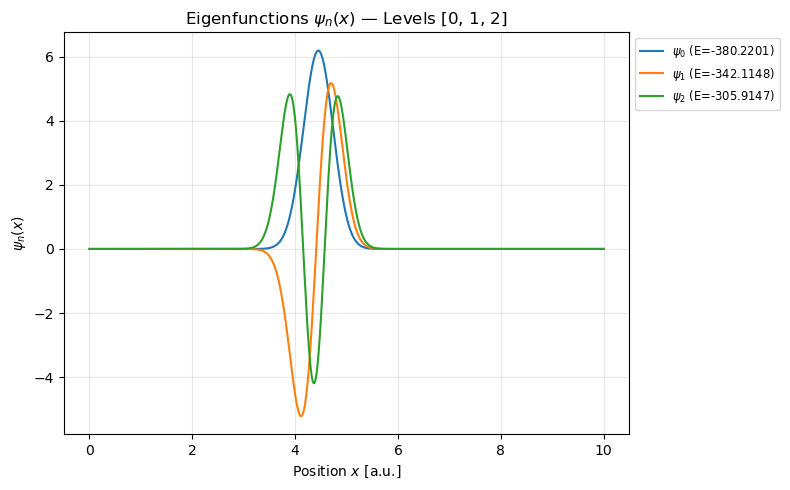

In [8]:
p.plot_eigenfunctions(num_levels=3)

In [9]:
n = p.norm_of_wave_function(coefficients=coefficients)
tempo = 10
for t in np.linspace(0, tempo, 11):
    print(f"Norm at t= {t:.1f}: {n(t):.15}")

Norm at t= 0.0: 0.999999999999355
Norm at t= 1.0: 0.999999999999563
Norm at t= 2.0: 0.999999999999964
Norm at t= 3.0: 1.00000000000016
Norm at t= 4.0: 1.00000000000003
Norm at t= 5.0: 0.999999999999831
Norm at t= 6.0: 0.999999999999858
Norm at t= 7.0: 1.00000000000013
Norm at t= 8.0: 1.0000000000004
Norm at t= 9.0: 1.00000000000042
Norm at t= 10.0: 1.00000000000013


In [10]:

dt = (0, 10)
p.expected_position_and_uncertainty_are_calculated(t_range=dt, coefficients=coefficients, num_points=300)

Expected position and uncertainty data stored in file: StiffMatter/StiffMatter_PositionUncertainty.txt


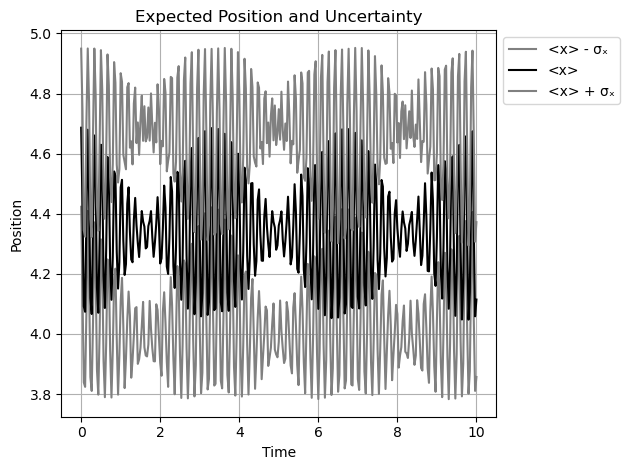

In [11]:
p.expected_position_and_uncertainty_are_plotted()

Minimum value of dx(t) / <x>(t): 0.056154201056187
Estimated period(s): 
t = 0.000000000000000
Full results saved at: StiffMatter/StiffMatter_min_relative_uncertainty.txt


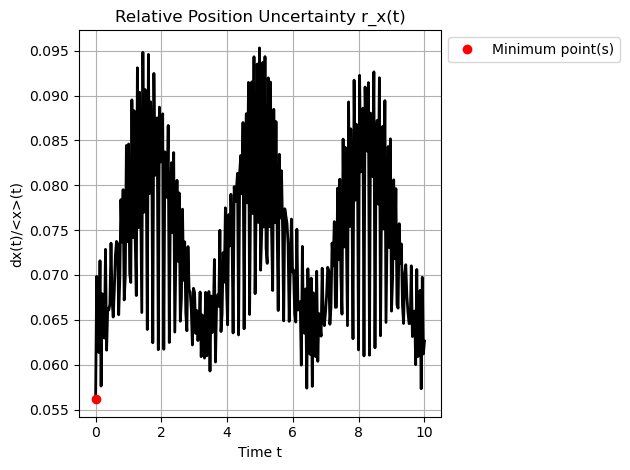

(<Figure size 640x480 with 1 Axes>,
 np.float64(0.05615420105618748),
 [np.float64(0.0)])

In [12]:
tempo = 10
pontos = 300
p.position_uncertainty_relative(coefficients, t_max=tempo, num_points=pontos)

In [13]:
# Cria a função ⟨p⟩(t)
P_t = p.expected_momentum(coefficients=coefficients)

P_t(0)
P_t(1)


np.float64(1.7993405875006094)

In [14]:
dp = p.momentum_uncertainty(coefficients)
dp(1)

np.float64(3.5244764230480112)

In [15]:
dt = (0.0, 10) # intervalo de tempo
points = 300 # número de pontos gerados
p.expected_momentum_and_uncertainty_are_calculated(dt, coefficients, points)


Expected momentum and uncertainty data stored in file: StiffMatter/StiffMatter_MomentumUncertainty.txt


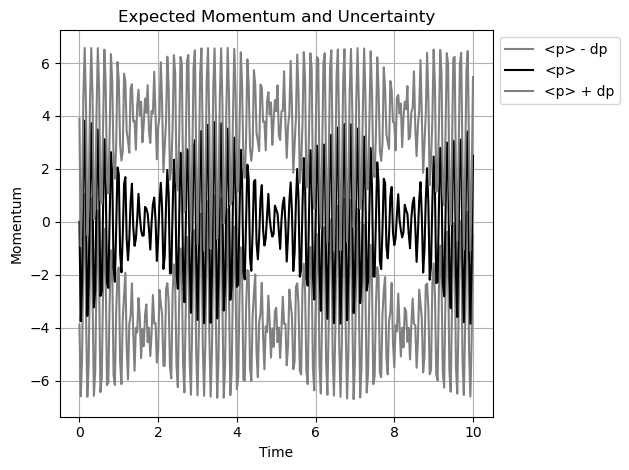

In [16]:
p.expected_momentum_and_uncertainty_are_plotted()

Minimum value of dp(t) / <p>(t): -389.317599998224409
Estimated period (s):
t = 2.107023411371237
Full results saved in: StiffMatter/StiffMatter_min_relative_momentum_uncertainty.txt


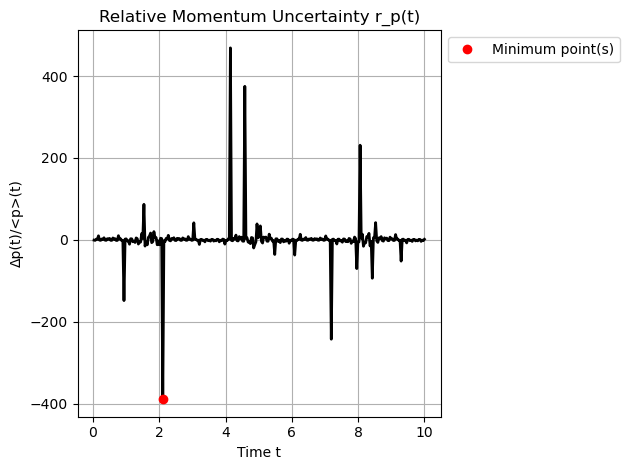

(<Figure size 640x480 with 1 Axes>,
 np.float64(-389.3175999982244),
 [np.float64(2.1070234113712374)])

In [17]:
tmax = 10
points = 300
p.momentum_uncertainty_relative(coefficients, t_max=tempo, num_points=points)

In [18]:
heis = p.heisenberg_uncertainty(coefficients)

# iteração para os primeiros dez valores inteiros
for i in range(0,11):
    print(f"t= {i} | {heis(i)}")

t= 0 | {'dx': np.float64(0.2631601226187416), 'dp': np.float64(3.896164793380968), 'dx.dp': np.float64(1.0253152047689598), 'hbar/2': 0.5, 'valid': np.True_}
t= 1 | {'dx': np.float64(0.3797509967756505), 'dp': np.float64(3.5244764230480112), 'dx.dp': np.float64(1.3384234347647614), 'hbar/2': 0.5, 'valid': np.True_}
t= 2 | {'dx': np.float64(0.3305749880338523), 'dp': np.float64(4.220307584103972), 'dx.dp': np.float64(1.395128129114347), 'hbar/2': 0.5, 'valid': np.True_}
t= 3 | {'dx': np.float64(0.3119054557335758), 'dp': np.float64(2.8530231062694242), 'dx.dp': np.float64(0.8898734721793868), 'hbar/2': 0.5, 'valid': np.True_}
t= 4 | {'dx': np.float64(0.2957678527581226), 'dp': np.float64(3.8659583039270298), 'dx.dp': np.float64(1.143426186404931), 'hbar/2': 0.5, 'valid': np.True_}
t= 5 | {'dx': np.float64(0.38705582136215383), 'dp': np.float64(3.7155360217800877), 'dx.dp': np.float64(1.4381198467107612), 'hbar/2': 0.5, 'valid': np.True_}
t= 6 | {'dx': np.float64(0.3000396726214886), 'dp

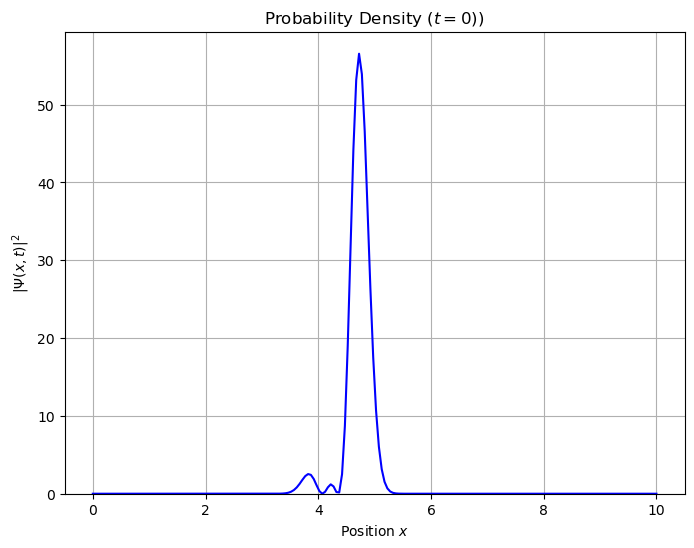

In [19]:
p.probability_density_is_plotted(t=0, coefficients=coefficients)

In [20]:
p.check_solutions_numerically()

Building matrices for verification...
Reporting errors in equations in file: StiffMatter/StiffMatter_Check_Equations.txt
Reporting errors in eigenvector normality in file: StiffMatter/StiffMatter_Check_Normality.txt
Reporting errors in eigenvector orthogonality in file: StiffMatter/StiffMatter_Check_Orthogonality.txt
Numerical verification Done.


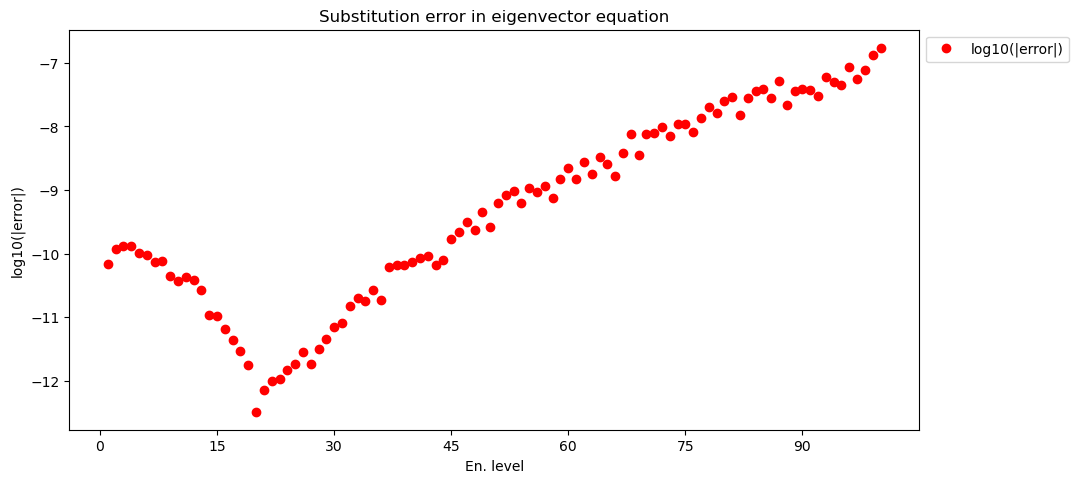

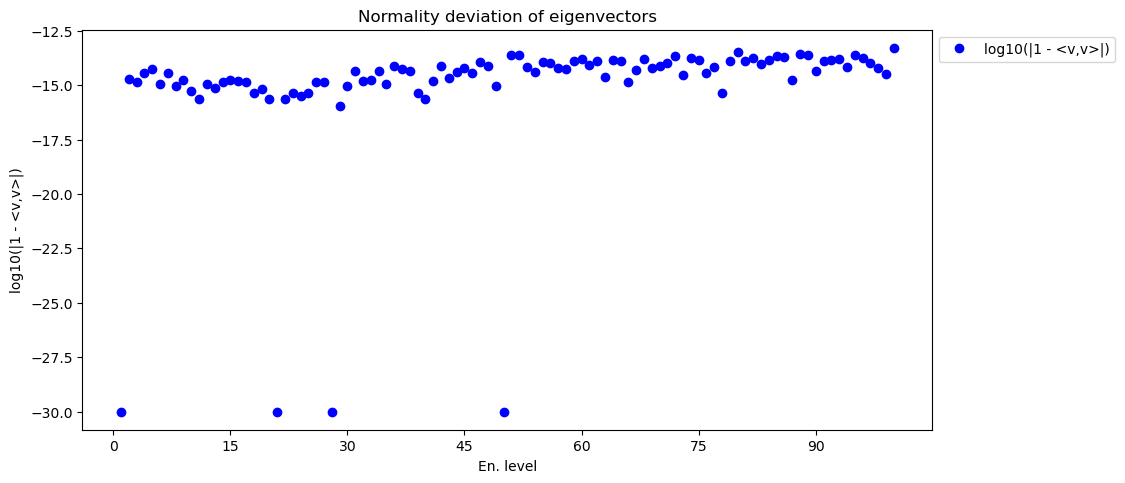

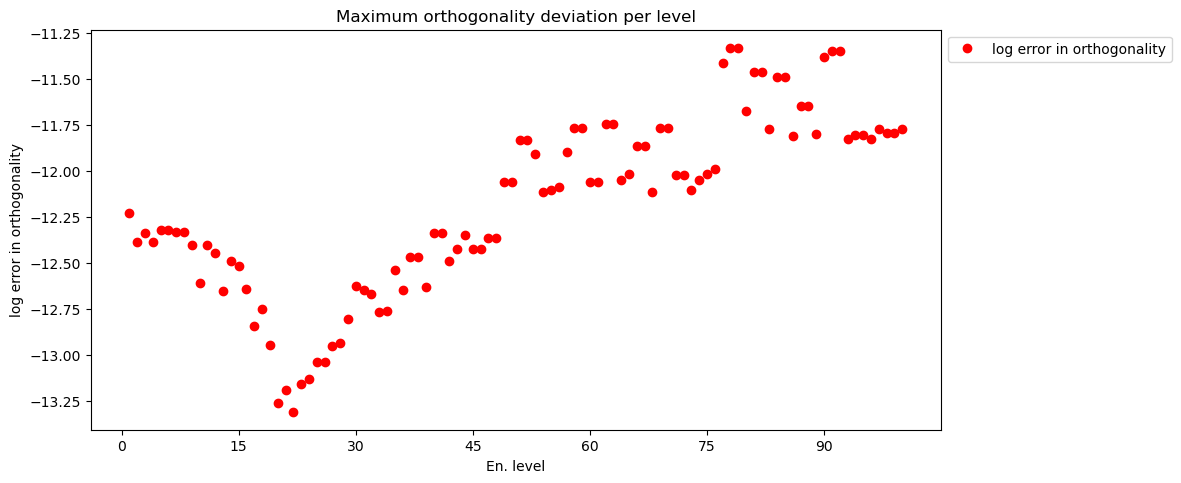

--------------------------------------------------------------------------------
---------------- Orthogonality Summary (2D curve) ----------------


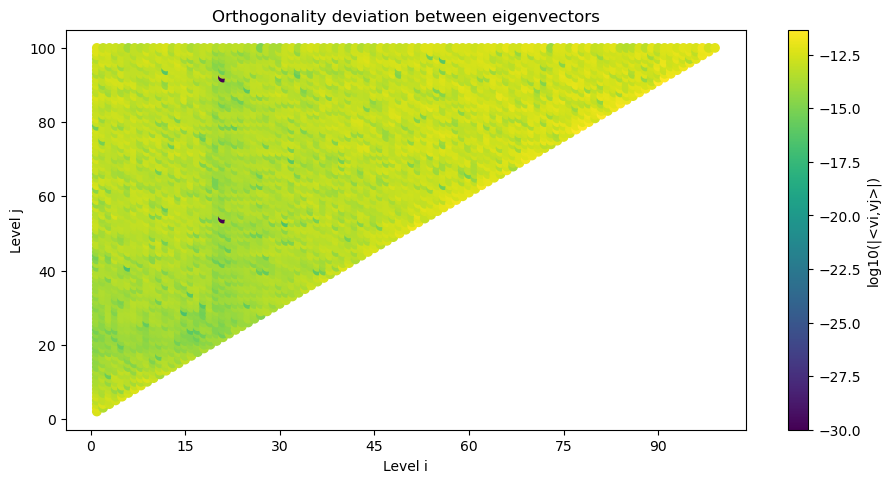

Graphical check Done.


In [21]:
p.check_solutions_graphically()

In [22]:
p.calculate_spectrum()

________________________________________________________________________________
Calculating energy eigenvalues...
________________________________________________________________________________
Finished eigenvalue calculation.
________________________________________________________________________________
Spectrum saved to: StiffMatter/StiffMatter_Spectrum.txt


[np.float64(-380.22012695022),
 np.float64(-342.1147708538197),
 np.float64(-305.91471592040614),
 np.float64(-271.6318932477189),
 np.float64(-239.27917734798697),
 np.float64(-208.87051288608345),
 np.float64(-180.4210664335063),
 np.float64(-153.94741001279823),
 np.float64(-129.4677456328548),
 np.float64(-107.00218356354394),
 np.float64(-86.57309243214863),
 np.float64(-68.20554750710195),
 np.float64(-51.92791690153015),
 np.float64(-37.77264804309943),
 np.float64(-25.777357343830474),
 np.float64(-15.986404678166519),
 np.float64(-8.45330365709397),
 np.float64(-3.244744268371265),
 np.float64(-0.4483923287503108),
 np.float64(0.045481978656609946),
 np.float64(0.19174297290673767),
 np.float64(0.5851613192304242),
 np.float64(1.3099261946653948),
 np.float64(2.4335106460435276),
 np.float64(4.021106209477628),
 np.float64(6.137784078233237),
 np.float64(8.849238560616293),
 np.float64(12.222517800199453),
 np.float64(16.326743739081284),
 np.float64(21.233818085535894),
 np.f

- EIGENVALUES

In [23]:
'''é necessário ter executado: p.calculate_spectrum() '''
#p.its_eigenvalues()              # retorna a lista completa de autovalores.
#p.its_eigenvalues(1)             # retorna o 1º autovalor.
#p.its_eigenvalues(slice(1,4))    # retorna os autovalores dos níveis 1, 2 e 3.
#p.its_eigenvalues(range(1,4))    # retorna os autovalores dos níveis 1, 2 e 3.
#p.its_eigenvalues(1, 3, 5)       # retorna uma lista com o 1º, o 3º e o 5º autovalor.
p.its_eigenvalues(slice(1, 10))

[np.float64(-380.22012695022),
 np.float64(-342.1147708538197),
 np.float64(-305.91471592040614),
 np.float64(-271.6318932477189),
 np.float64(-239.27917734798697),
 np.float64(-208.87051288608345),
 np.float64(-180.4210664335063),
 np.float64(-153.94741001279823),
 np.float64(-129.4677456328548)]

- EIGENVECTORS

In [24]:
a = p.its_eigenvectors(1)

- EIGENFUNCTION

In [25]:
#''' NUMERIC '''
# Retorna o valor numérico para x=0.5
psi_val = p.its_eigenfunction(0.5, 2)
print("Eigenfunction value at x=0.5:", psi_val)

Eigenfunction value at x=0.5: -1.1469307788002401e-14


- WAVE FUNCTION

In [26]:
#''' NUMERIC '''
# Lista de coeficientes para os 100 primeiros níveis (exemplo: coeficientes aleatórios)
coefficients = [1, 1, 1] + [0] * 97  
# Avaliação numérica da função de onda para x = 0.5 e t = 2.0
psi_val = p.wave_function(0.5, 2.0, coefficients)

# Exibir o resultado numérico
print(f"Wave Function at x=0.5, t=2.0: {psi_val}")

Wave Function at x=0.5, t=2.0: (-2.060212420426587e-15+3.2814535348239364e-15j)


In [27]:
#''' SIMBOLIC '''
#coefficients = [np.exp(-0.1 * n) for n in range(100)]  # Exemplo de distribuição decrescente
coefficients = [1, 1, 1] + [0] * 97  

# Chamada da função para gerar a expressão simbólica
expr = p.wave_function("x", "t", coefficients)

# Exibir a expressão de forma legível
expr

(0.00423294513102646*sin(0.1*pi*x) - 0.124157247006994*sin(0.2*pi*x) - 0.0954353388659855*sin(0.3*pi*x) + 0.186384655897096*sin(0.4*pi*x) + 0.236172189587908*sin(pi*x/2) - 0.153444014556362*sin(0.6*pi*x) - 0.363422632902591*sin(0.7*pi*x) + 0.0346546188895033*sin(0.8*pi*x) + 0.422299599620091*sin(0.9*pi*x) + 0.125275383739476*sin(pi*x) - 0.389266768454059*sin(1.1*pi*x) - 0.269004887592119*sin(1.2*pi*x) + 0.278380739597201*sin(1.3*pi*x) + 0.351941170541144*sin(1.4*pi*x) - 0.129970091067684*sin(3*pi*x/2) - 0.357832057602501*sin(1.6*pi*x) - 0.00989297239916603*sin(1.7*pi*x) + 0.299254763746606*sin(1.8*pi*x) + 0.107873387662059*sin(1.9*pi*x) - 0.206166646397635*sin(2*pi*x) - 0.152104696097838*sin(2.1*pi*x) + 0.110588118268947*sin(2.2*pi*x) + 0.150053636331723*sin(2.3*pi*x) - 0.0350616693497892*sin(2.4*pi*x) - 0.119714773363674*sin(5*pi*x/2) - 0.0115225678736049*sin(2.6*pi*x) + 0.0799761604243485*sin(2.7*pi*x) + 0.031617304259366*sin(2.8*pi*x) - 0.0443121465205732*sin(2.9*pi*x) - 0.033595740

 - PROBABILITY DENSITY

In [28]:
''' NUMERIC '''
coefficients = [1, 1, 1] + [0] * 97  
# Avaliando a densidade de probabilidade para valores específicos: x=0.5, t=2.0
psi_val = p.probability_density(0.5, 2.0, coefficients)
print("Wave function probability density at x=0.5, t=2.0:", psi_val)

Wave function probability density at x=0.5, t=2.0: 1.501241251848848e-29


In [29]:
#''' SIMBOLIC '''

# 'p' é o objeto que contém o método wave_function,
#  os autovetores já foram calculados.
#coefficients = [0.1] * 100  # Exemplo: 100 níveis com coeficiente 0.1 para cada.
coefficients = [1, 1, 1] + [0] * 97  
# x e t passados como strings para obter uma expressão simbólica
expr = p.probability_density("x", "t", coefficients)
expr

Abs((0.00423294513102646*sin(0.1*pi*x) - 0.124157247006994*sin(0.2*pi*x) - 0.0954353388659855*sin(0.3*pi*x) + 0.186384655897096*sin(0.4*pi*x) + 0.236172189587908*sin(pi*x/2) - 0.153444014556362*sin(0.6*pi*x) - 0.363422632902591*sin(0.7*pi*x) + 0.0346546188895033*sin(0.8*pi*x) + 0.422299599620091*sin(0.9*pi*x) + 0.125275383739476*sin(pi*x) - 0.389266768454059*sin(1.1*pi*x) - 0.269004887592119*sin(1.2*pi*x) + 0.278380739597201*sin(1.3*pi*x) + 0.351941170541144*sin(1.4*pi*x) - 0.129970091067684*sin(3*pi*x/2) - 0.357832057602501*sin(1.6*pi*x) - 0.00989297239916603*sin(1.7*pi*x) + 0.299254763746606*sin(1.8*pi*x) + 0.107873387662059*sin(1.9*pi*x) - 0.206166646397635*sin(2*pi*x) - 0.152104696097838*sin(2.1*pi*x) + 0.110588118268947*sin(2.2*pi*x) + 0.150053636331723*sin(2.3*pi*x) - 0.0350616693497892*sin(2.4*pi*x) - 0.119714773363674*sin(5*pi*x/2) - 0.0115225678736049*sin(2.6*pi*x) + 0.0799761604243485*sin(2.7*pi*x) + 0.031617304259366*sin(2.8*pi*x) - 0.0443121465205732*sin(2.9*pi*x) - 0.03359

- Plotting the probability density

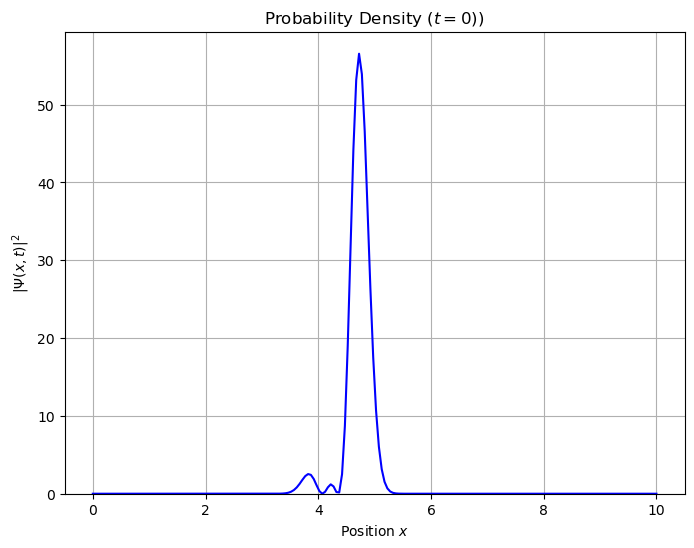

In [30]:
# Tempo t = 0
t_value = 0

#p.probability_density_is_plotted(t_value, coefficients, num_slices=200, color='blue', title="Probabilidade |ψ(x,t=0)|²", xlabel="Posição x", ylabel="|ψ(x,t)|²")
p.probability_density_is_plotted(t_value, coefficients)


Computing density frames…


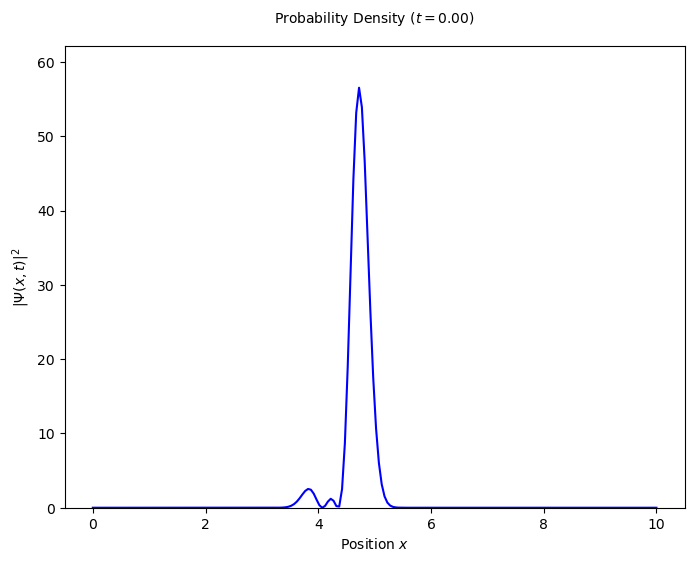

In [31]:
# Intervalo de tempo de 0 a 20
time_interval = (0, 20)

# Chamada para gerar a animação com o padrão (10 frames)
#p.probability_density_is_plotted(time_interval, coefficients, num_frames=10, num_slices=200, color='blue', title="Probabilidade |ψ(x,t)|²",		 xlabel="Posição x", ylabel="|ψ(x,t)|²")

p.probability_density_is_plotted(time_interval, coefficients)

Computing density frames…


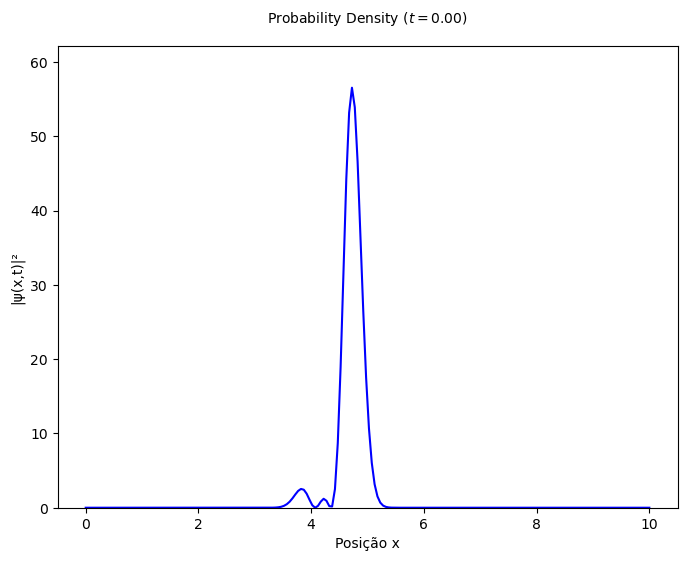

In [32]:
# Ou para gerar uma animação com 20 frames:
p.probability_density_is_plotted(time_interval, coefficients, num_frames=100, num_slices=200,
                                 save_as_gif=True, gif_filename="stiff_prob_density.gif",
                                 color='blue', title="Probabilidade |ψ(x,t)|²",
                                 xlabel="Posição x", ylabel="|ψ(x,t)|²")

- Plotting the probability density (3D version)

In [33]:
# Intervalo de tempo para o gráfico 3D: por exemplo, de t=0 até t=20
t_interval = (0, 20)

# Chama o método para gerar o gráfico 3D estático
p.probability_density_3d(t_interval, coefficients, num_frames=50, num_slices=200,
                          cmap='plasma', title="Gráfico 3D da Densidade de Probabilidade",
                          xlabel="Posição x", ylabel="Tempo t", zlabel="|ψ(x,t)|²")

Computing 3D surface...
-> 3D GIF saved: StiffMatter/StiffMatter_probability_density_3d.gif


(<Figure size 1000x800 with 2 Axes>,
 <Axes3D: title={'center': 'Gráfico 3D da Densidade de Probabilidade'}, xlabel='Posição x', ylabel='Tempo t', zlabel='|ψ(x,t)|²'>,
 array([[0.00000000e+00, 2.62823115e-31, 1.58408705e-31, ...,
         8.11512920e-29, 2.76570139e-29, 1.28192704e-29],
        [0.00000000e+00, 3.08907493e-32, 2.28224187e-31, ...,
         6.60229143e-29, 9.99977300e-30, 2.49177947e-29],
        [0.00000000e+00, 8.58605436e-32, 1.34420672e-30, ...,
         8.62532732e-29, 1.44145596e-29, 5.04041179e-29],
        ...,
        [0.00000000e+00, 9.53529334e-33, 3.32085982e-31, ...,
         5.93530404e-30, 1.16679080e-30, 9.89900200e-30],
        [0.00000000e+00, 1.78938636e-31, 8.18755834e-31, ...,
         1.68849224e-28, 3.14763611e-29, 5.89905331e-29],
        [0.00000000e+00, 8.27451341e-32, 1.11897318e-30, ...,
         1.91750073e-28, 2.72356677e-29, 7.85799464e-29]]),
 array([ 0.        ,  0.40816327,  0.81632653,  1.2244898 ,  1.63265306,
         2.04081633,  2.

In [34]:
# # Definição dos coeficientes: 3 primeiros = 1, restantes = 0 (total de 100 níveis)
# coefficients = [1, 1, 1] + [0] * 97

# # Intervalo de tempo para o gráfico 3D: por exemplo, de t=0 até t=20
# t_interval = (0, 20)

# # Chama o método para gerar o gráfico dinâmico, salvando-o em um arquivo .gif
# p.probability_density_3d(t_interval, coefficients, num_frames=100, num_slices=200,
#                          animate_rotation=True, save_as_gif=True, gif_filename="prob_density_3d.gif",
#                          cmap='plasma', title="Gráfico 3D da Densidade de Probabilidade",
#                          xlabel="Posição x", ylabel="Tempo t", zlabel="|ψ(x,t)|²")

- Expected position and Uncertainty

In [35]:
av = p.expected_position(coefficients=coefficients)
print(f'Expected position at t=0: {av(0):.20}')

un = p.position_uncertainty(coefficients=coefficients)
print(f'Position uncertainty at t=0: {un(0):.20}')

Expected position at t=0: 4.6863835237442970083
Position uncertainty at t=0: 0.26316012261874160982


- Calculating the expected value and uncertainty of position and saving data to a ﬁle

In [36]:
#Sem especificar o número de subintervalos (usa o valor padrão, por exemplo, 10):
p.expected_position_and_uncertainty_are_calculated((0.0, 20.0), coefficients=coefficients)

Calculating 300 points by default.
Expected position and uncertainty data stored in file: StiffMatter/StiffMatter_PositionUncertainty.txt


In [37]:
# Especificando o número de subintervalos:
p.expected_position_and_uncertainty_are_calculated((0.0, 20.0), coefficients, 200)

Expected position and uncertainty data stored in file: StiffMatter/StiffMatter_PositionUncertainty.txt


In [38]:
# Sem especificar o número de subintervalos (usa o valor padrão):
p.expected_position_is_calculated((0.0, 20.0), coefficients)

Calculating 300 points by default.
Data on expected position has been stored in file: StiffMatter/StiffMatter_Position.txt


In [39]:
#Especificando o número de subintervalos:
p.expected_position_is_calculated((0.0, 20.0), coefficients, 200)

Calculating 200 points.
Data on expected position has been stored in file: StiffMatter/StiffMatter_Position.txt


- Plotting the expected value and uncertainty of position

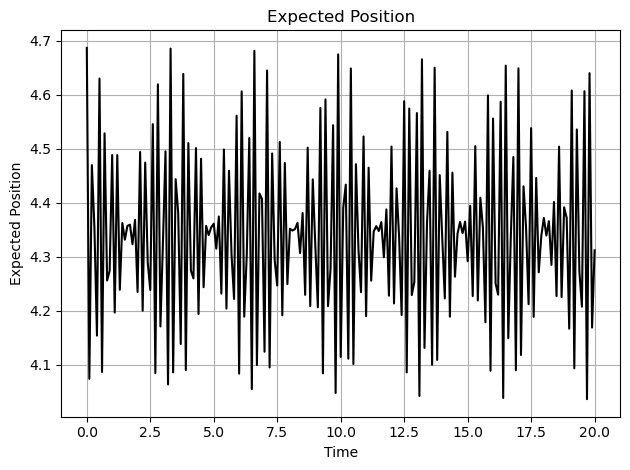

In [40]:
p.expected_position_is_plotted()

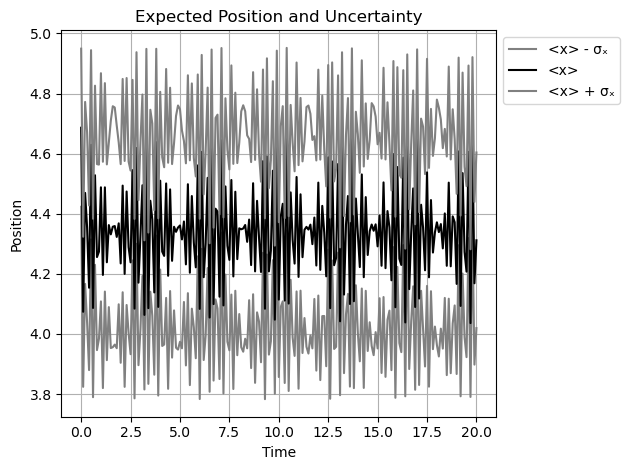

In [41]:
p.expected_position_and_uncertainty_are_plotted()

- Calculating the norm of the wave function

In [42]:
n = p.norm_of_wave_function(coefficients)

# podemos avaliar a função gerada utilizando um método iterativo para avaliar a norma em diferentes instantes de tempo.
for t in np.linspace(0, 100, 100):
    print(f"Norm at t= {t:.1f}: {n(t):.15f}")

Norm at t= 0.0: 0.999999999999355
Norm at t= 1.0: 0.999999999999462
Norm at t= 2.0: 0.999999999999719
Norm at t= 3.0: 0.999999999999984
Norm at t= 4.0: 1.000000000000132
Norm at t= 5.1: 1.000000000000131
Norm at t= 6.1: 1.000000000000047
Norm at t= 7.1: 0.999999999999977
Norm at t= 8.1: 0.999999999999989
Norm at t= 9.1: 1.000000000000090
Norm at t= 10.1: 1.000000000000235
Norm at t= 11.1: 1.000000000000348
Norm at t= 12.1: 1.000000000000348
Norm at t= 13.1: 1.000000000000194
Norm at t= 14.1: 0.999999999999917
Norm at t= 15.2: 0.999999999999626
Norm at t= 16.2: 0.999999999999456
Norm at t= 17.2: 0.999999999999481
Norm at t= 18.2: 0.999999999999659
Norm at t= 19.2: 0.999999999999858
Norm at t= 20.2: 0.999999999999948
Norm at t= 21.2: 0.999999999999898
Norm at t= 22.2: 0.999999999999783
Norm at t= 23.2: 0.999999999999727
Norm at t= 24.2: 0.999999999999806
Norm at t= 25.3: 1.000000000000008
Norm at t= 26.3: 1.000000000000247
Norm at t= 27.3: 1.000000000000422
Norm at t= 28.3: 1.00000000000

- Checking solutions

In [43]:
p.check_solutions_numerically()

Building matrices for verification...
Reporting errors in equations in file: StiffMatter/StiffMatter_Check_Equations.txt
Reporting errors in eigenvector normality in file: StiffMatter/StiffMatter_Check_Normality.txt
Reporting errors in eigenvector orthogonality in file: StiffMatter/StiffMatter_Check_Orthogonality.txt
Numerical verification Done.


- Graphically displaying error checkings.

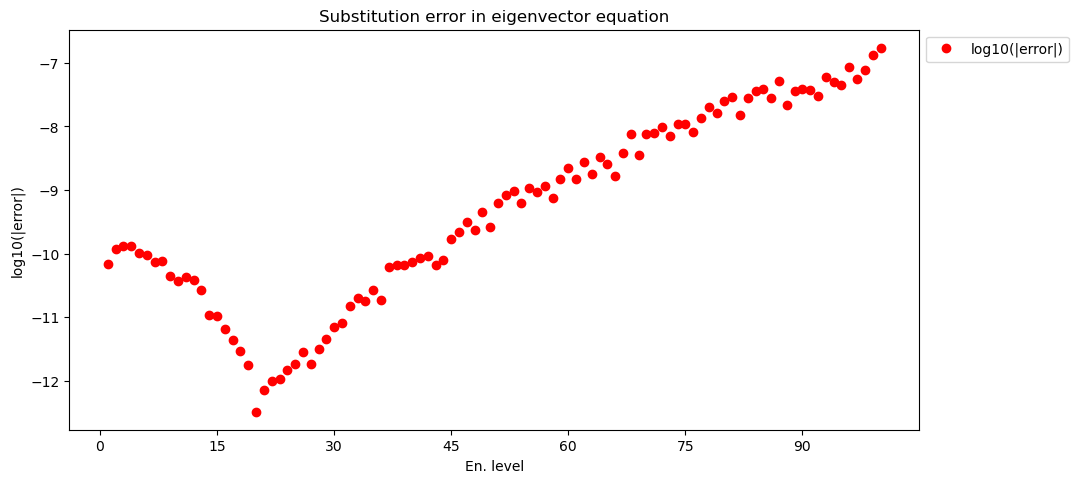

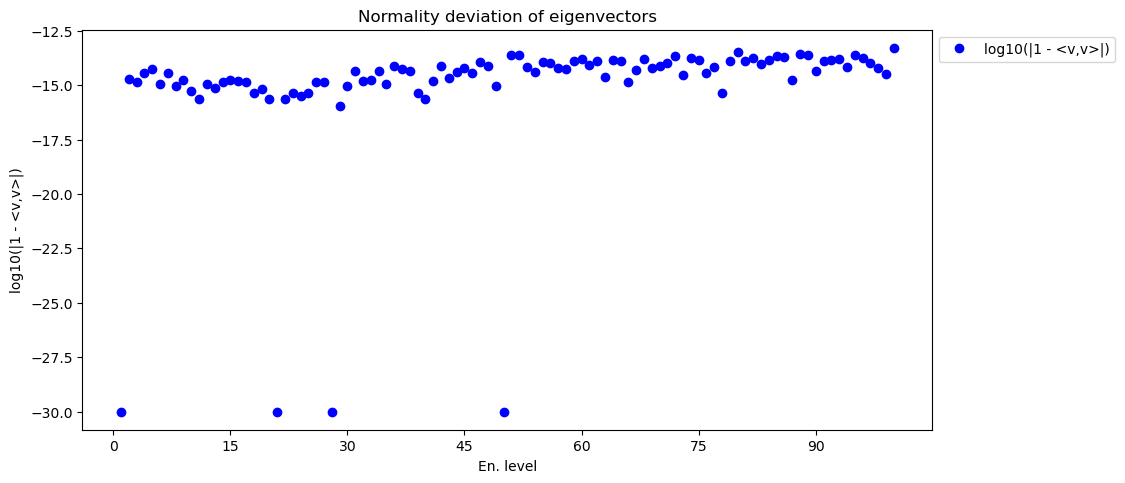

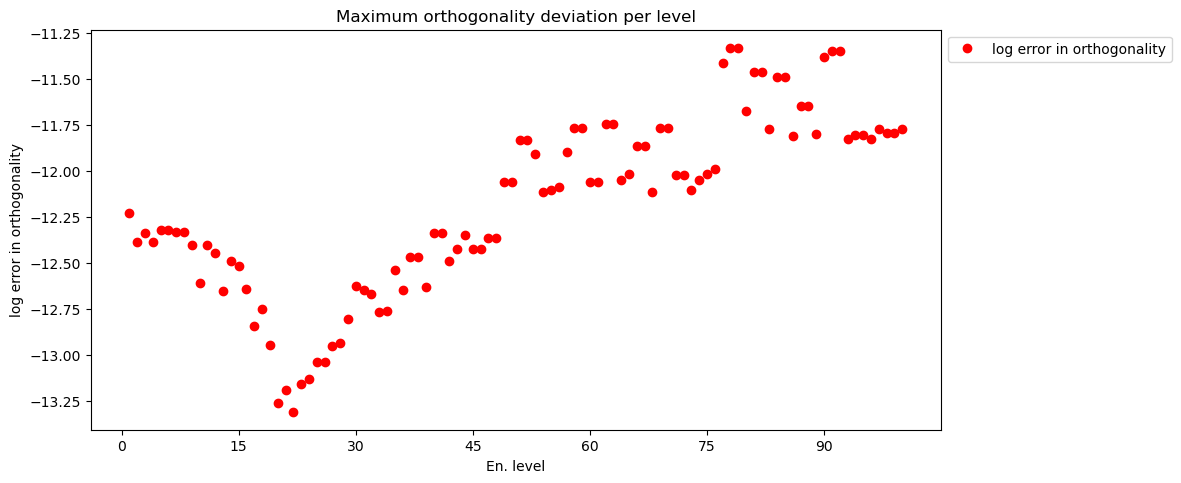

--------------------------------------------------------------------------------
---------------- Orthogonality Summary (2D curve) ----------------


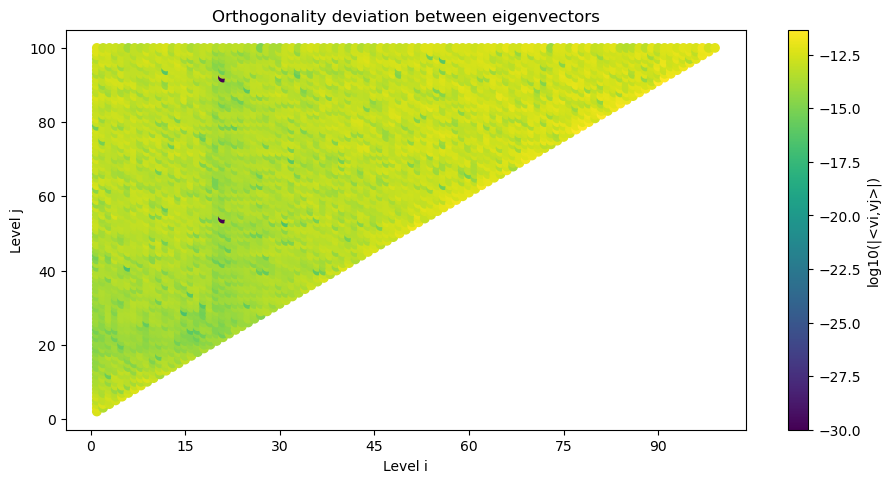

Graphical check Done.


In [44]:
p.check_solutions_graphically()


- Comparison of solutions

In [45]:
''' definição do problema '''
def f(x):
    return x**4
def g(x):
    return 1
    
q = SpectralMethod(num_levels=100, length=10.0, f_function=f, g_function=g, num_digits=15, label="HalfOscillator2")

Directory 'output' created successfully.


In [46]:
b = q.calculate_spectrum()

________________________________________________________________________________
Calculating energy eigenvalues...
________________________________________________________________________________
Finished eigenvalue calculation.
________________________________________________________________________________
Spectrum saved to: output/output_Spectrum.txt


In [47]:
p.compare_numerically(q)

Writing comparison to StiffMatter/StiffMatter_Comparison_Eigenvalues.txt...
Description has been written to file: StiffMatter/StiffMatter_Comparison_Eigenvalues.txt
Description has been written to file: StiffMatter/StiffMatter_Comparison_Eigenvalues.txt
Done.


Description of the caller problem:
--------------------------------------------------------------------------------
Number of energy levels:       100
Interval amplitude (Length):   10.0 (float: 10.0)
f function (V_spectral):       -36*(x**2)+1.2*(x**4)
g function:                    12/(x**2)
w function (weigth):           1/(x**2)
Label:                         StiffMatter
Number of digits to be used:   15
The energy eigenvalues and eigenvectors have been calculated with 15 digits by Python.
--------------------------------------------------------------------------------
Important: when using the spectral method, the potential must be expressed as V_spectral = 2*m*V_real.


Description of the called problem:
--------------------------------------------------------------------------------
Number of energy levels:       100
Interval amplitude (Length):   10.0 (float: 10.0)
f function (V_spectral):       x**4
g function:                    1
w function (weigth):           self.weight = 

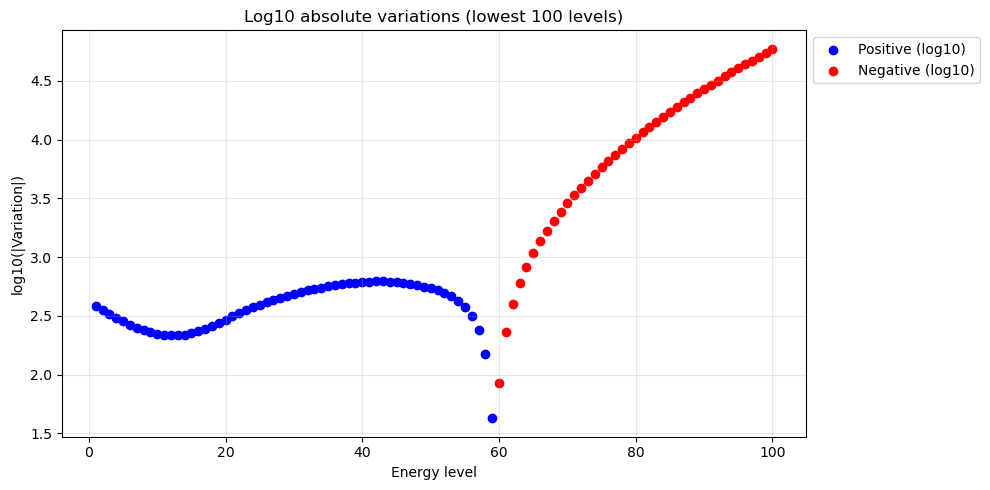

--------------------------------------------------------------------------------
Percent variation.



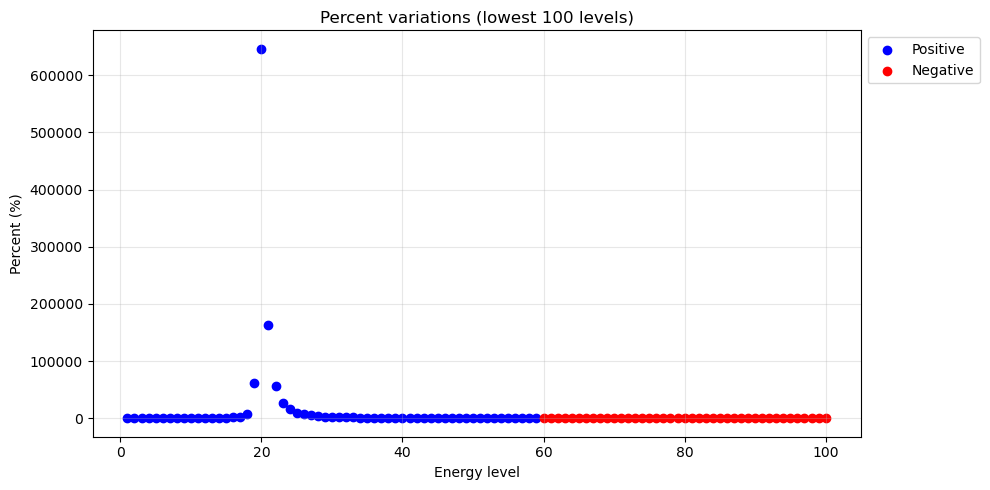

--------------------------------------------------------------------------------
Comparing orthogonality of eigenvectors (dot product).



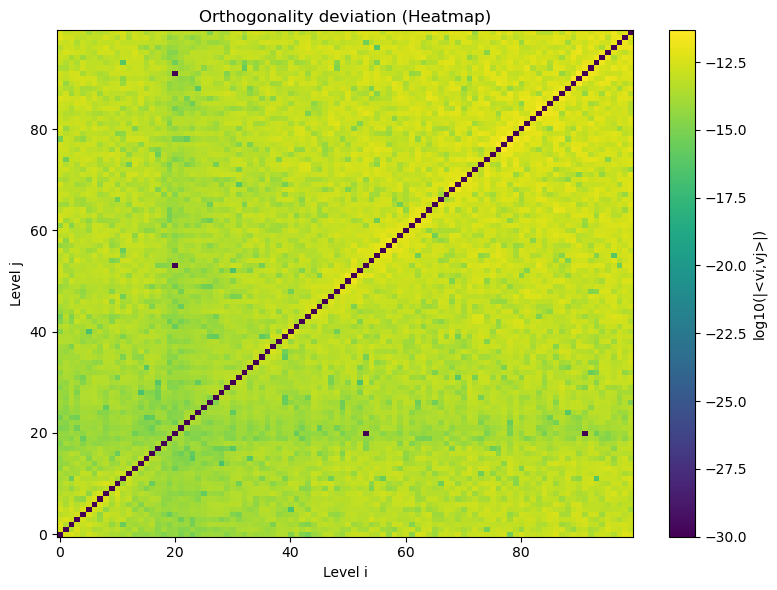

Generating individual orthogonality plots...


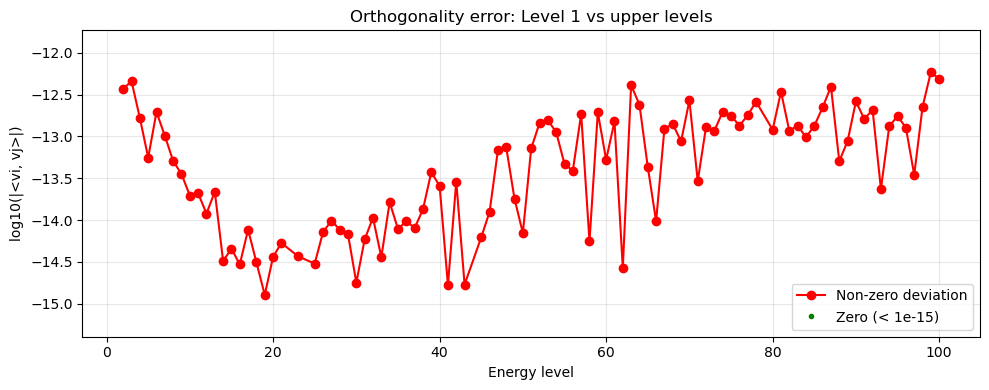

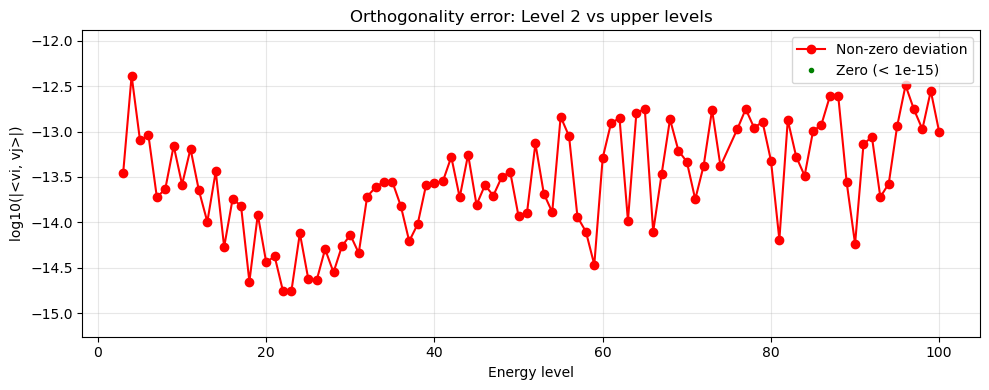

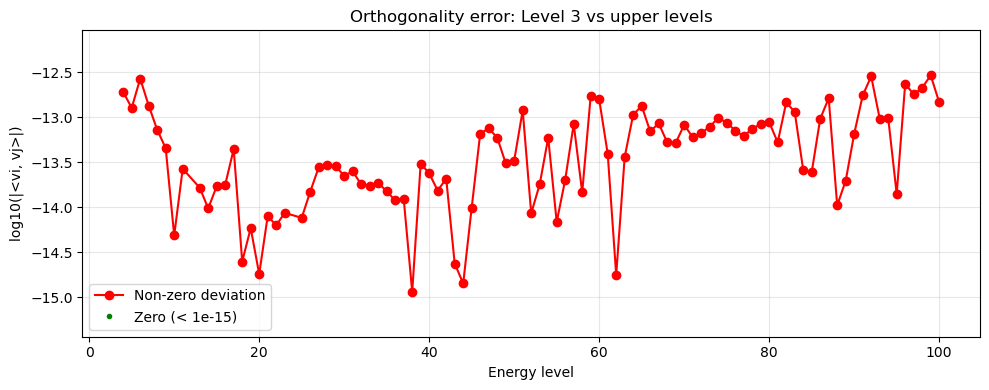

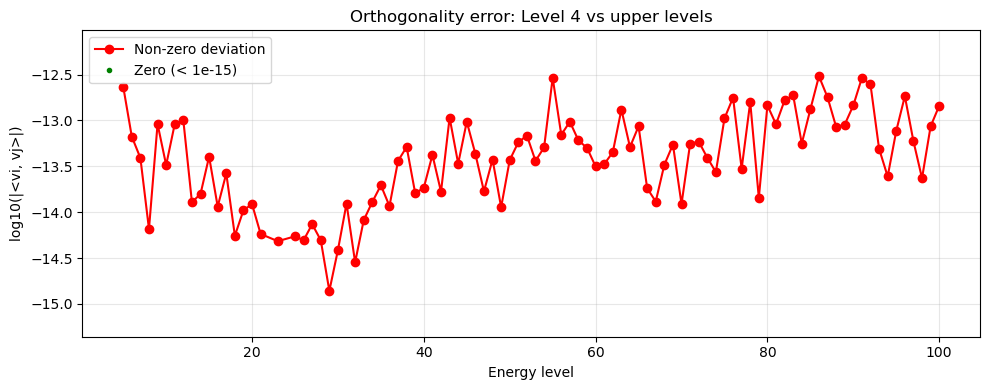

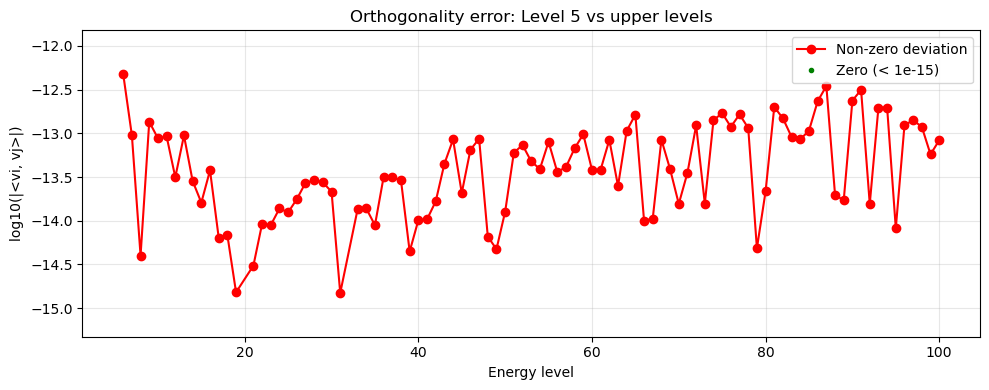

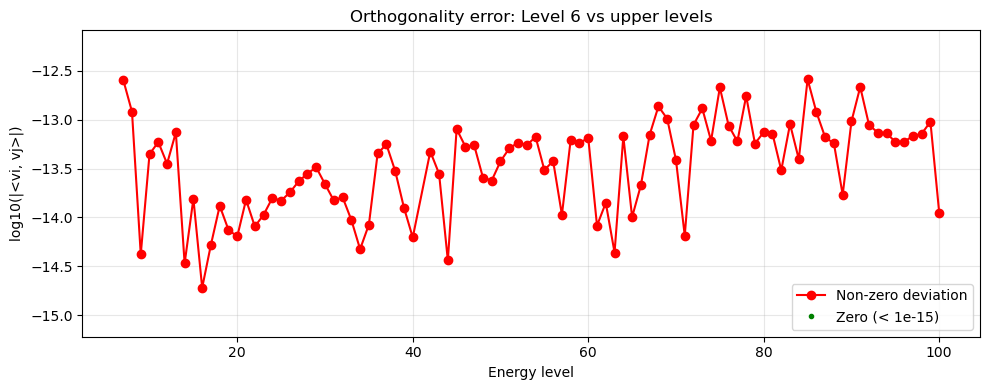

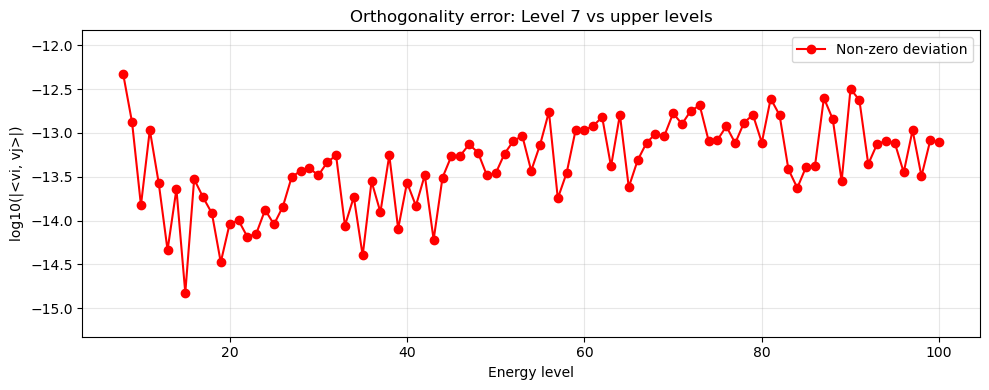

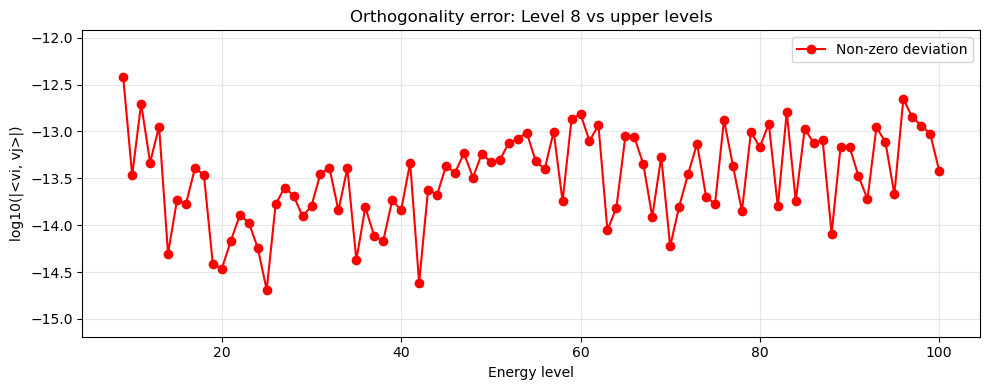

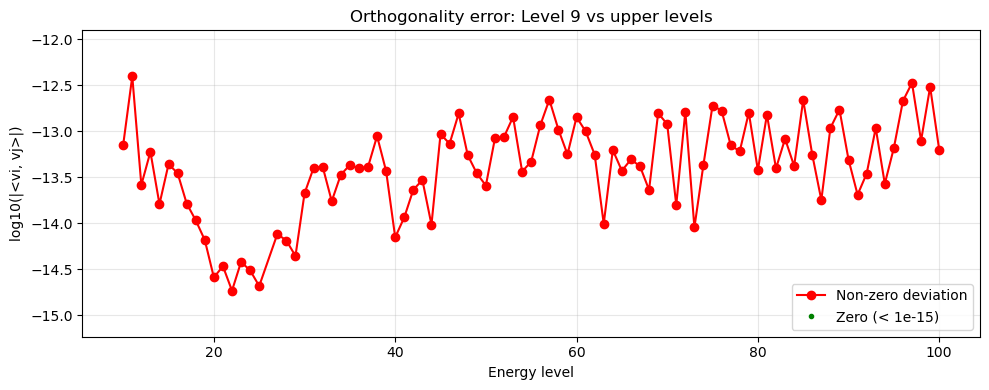

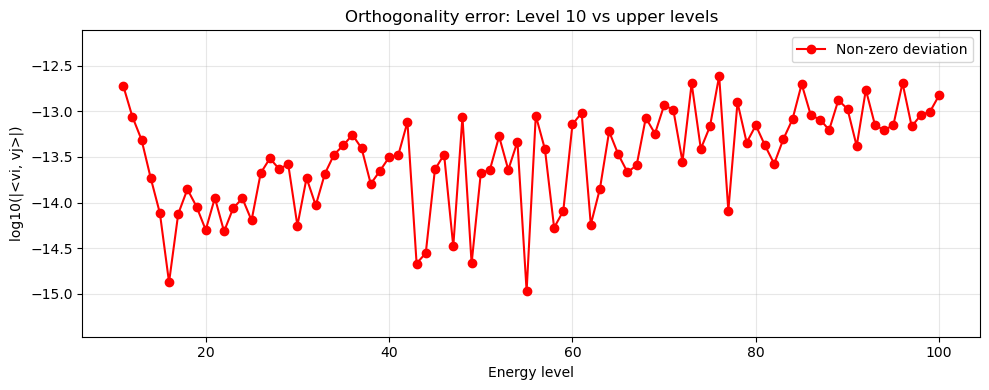

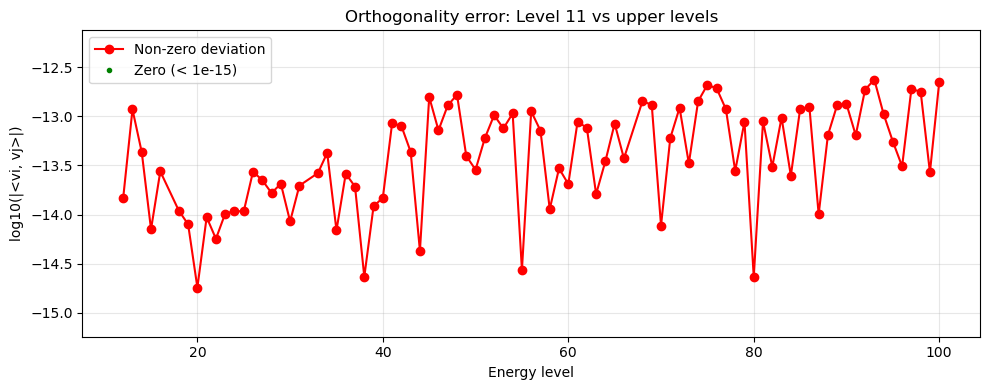

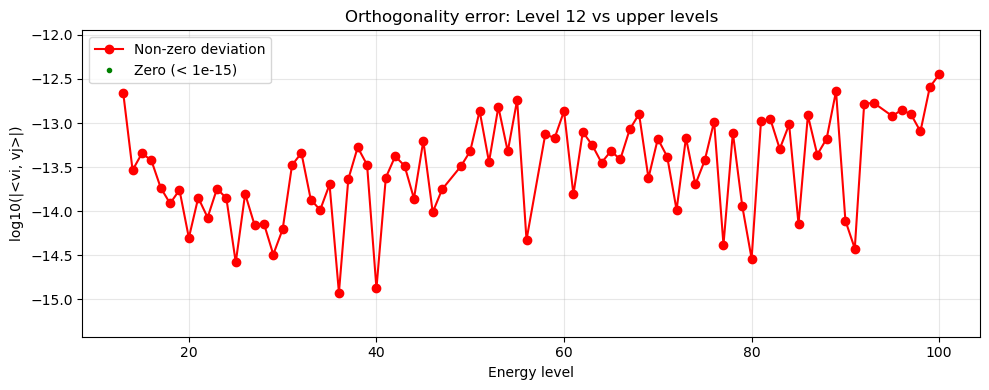

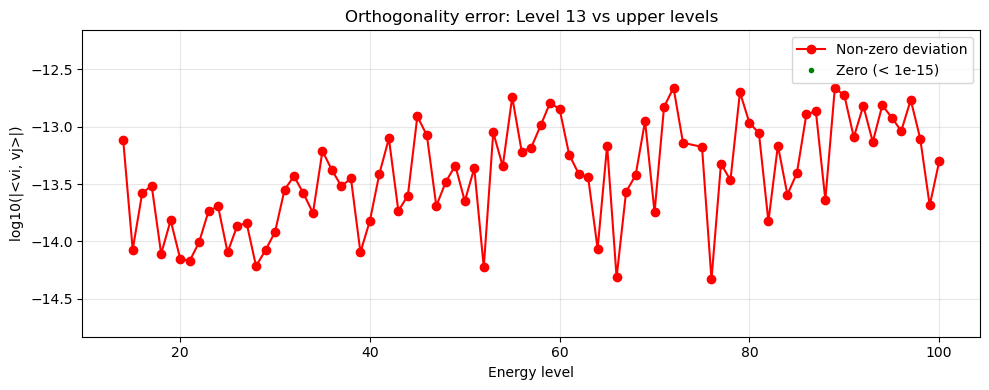

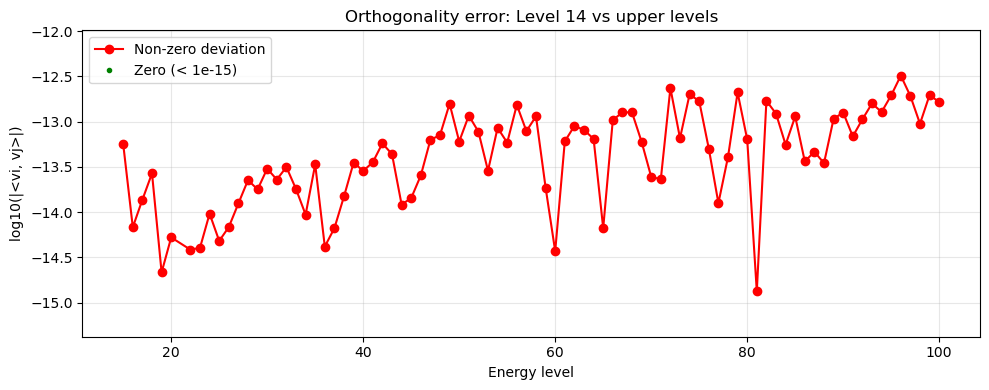

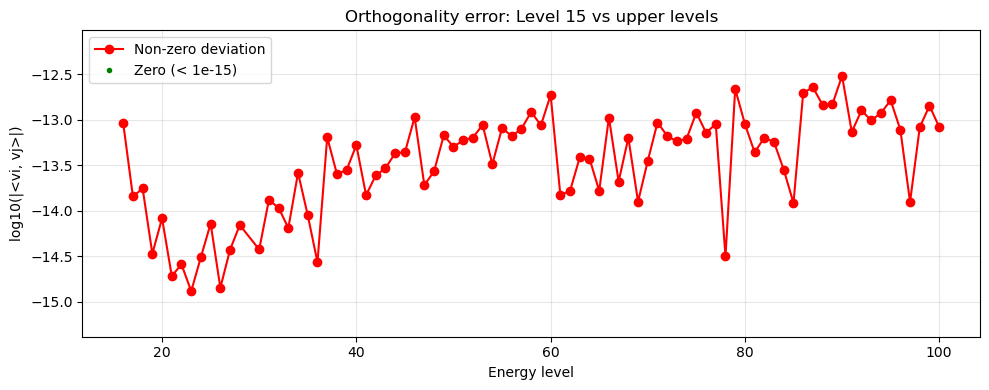

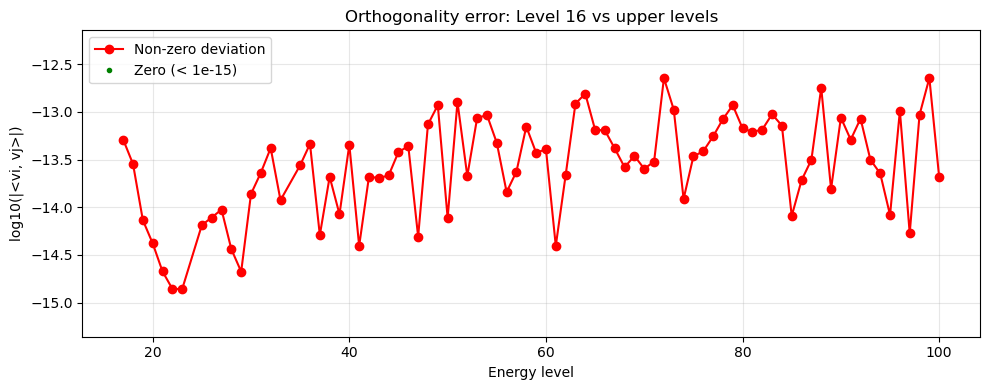

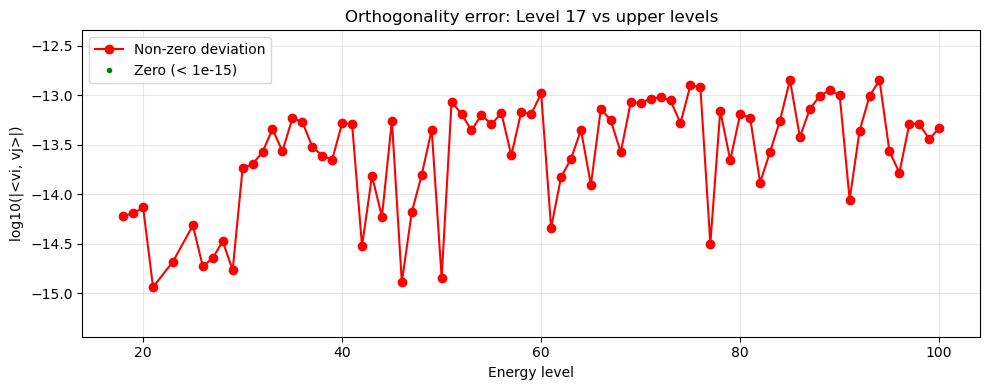

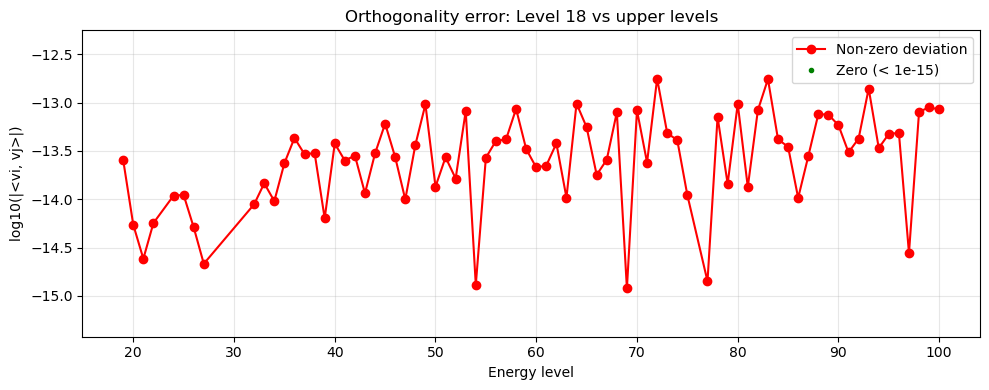

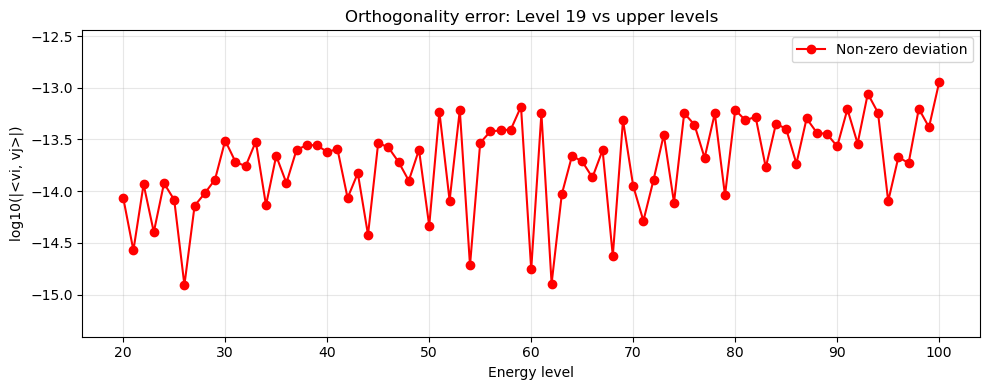

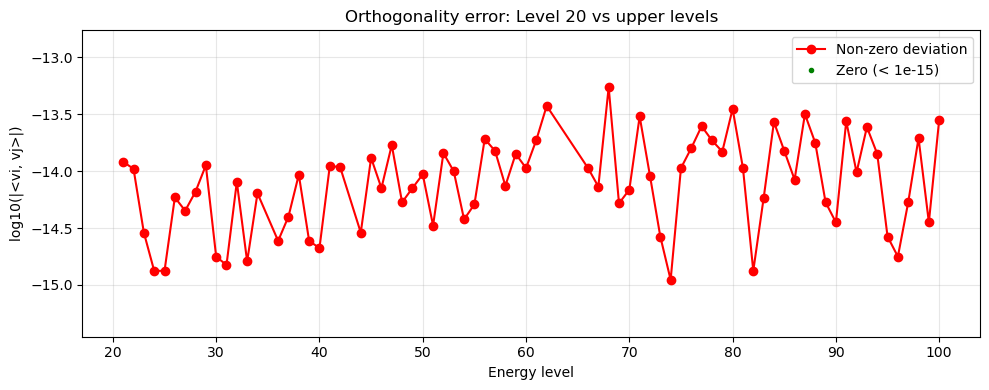

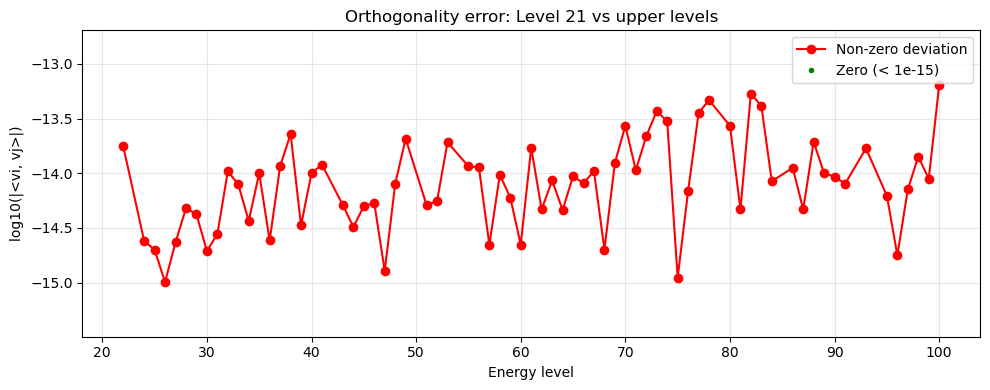

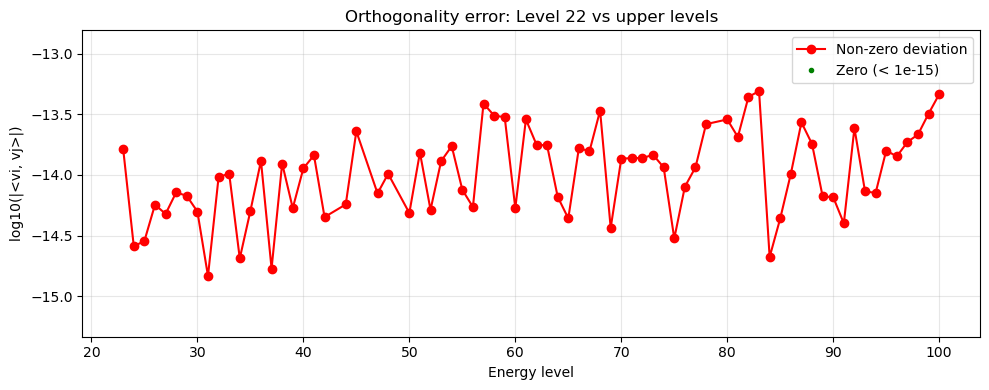

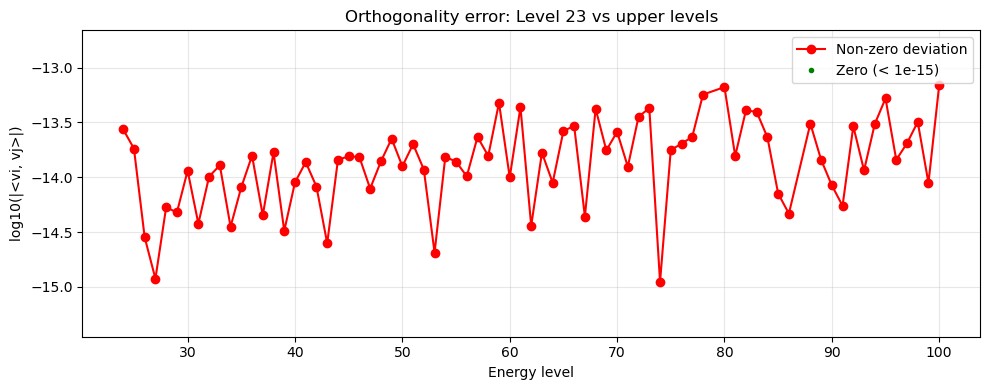

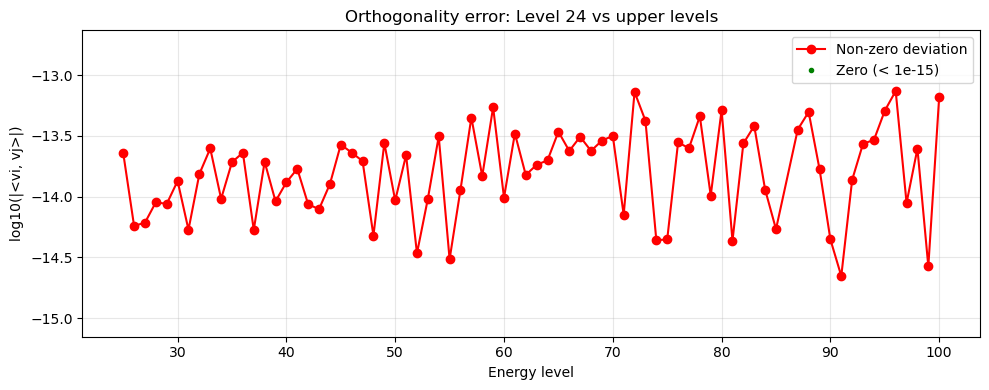

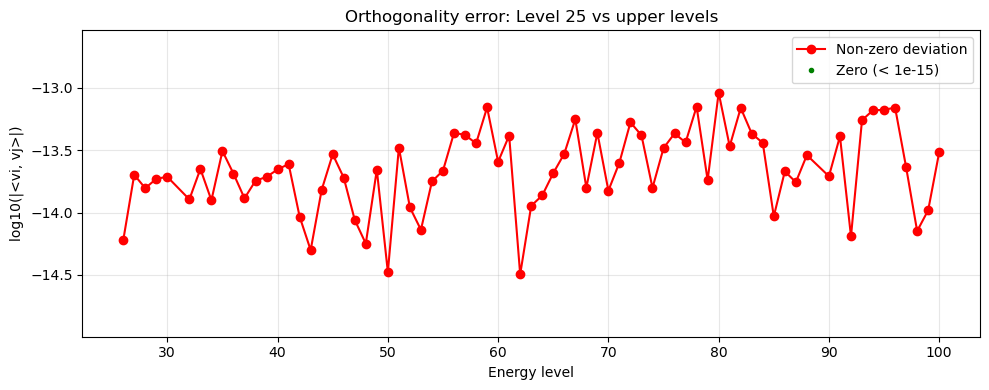

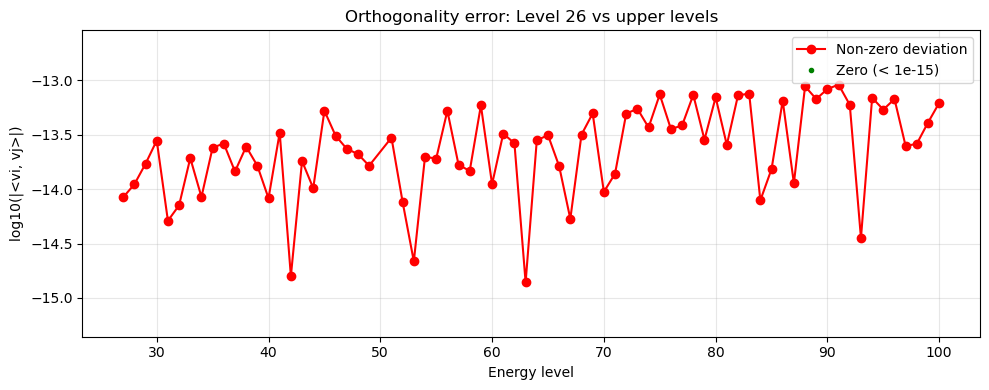

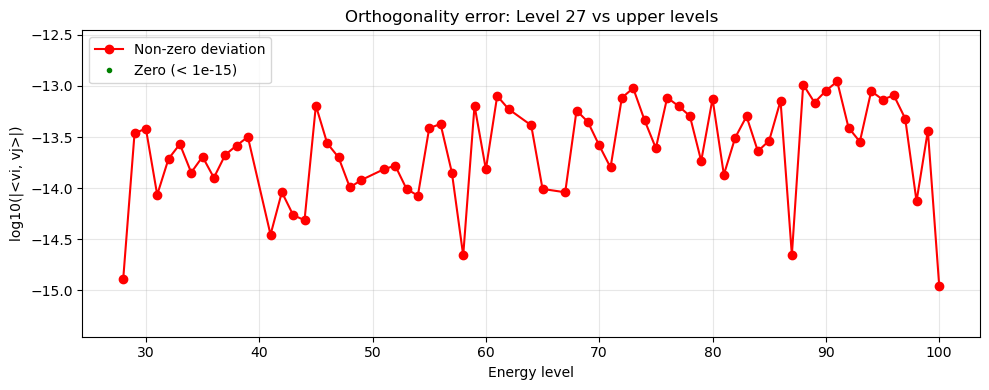

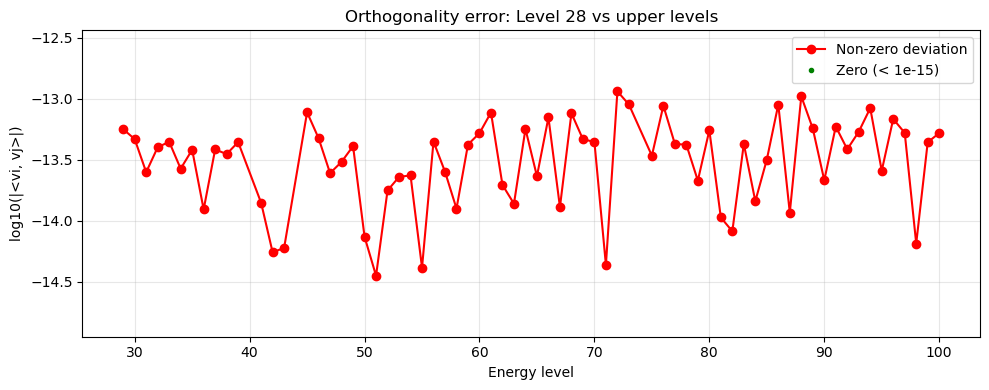

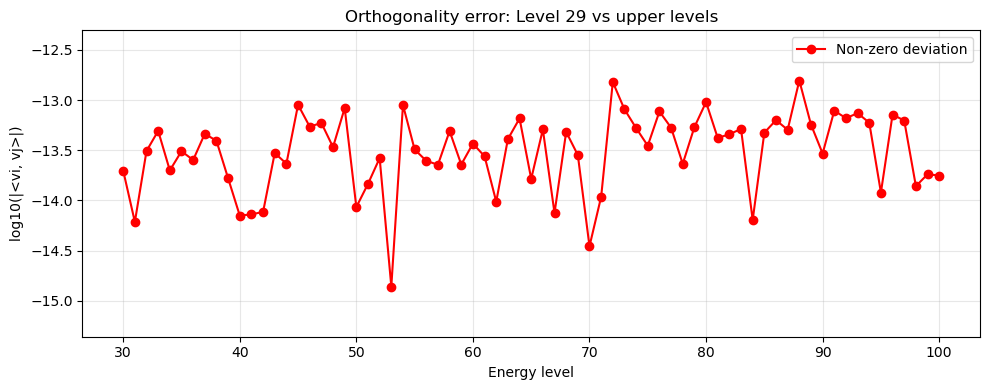

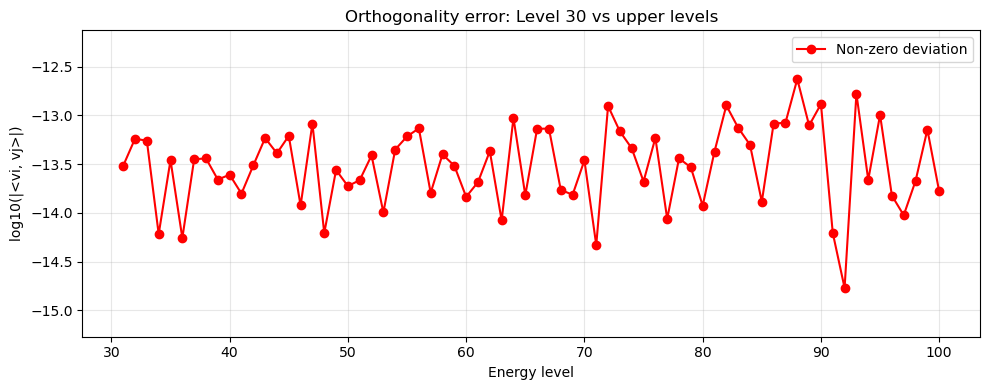

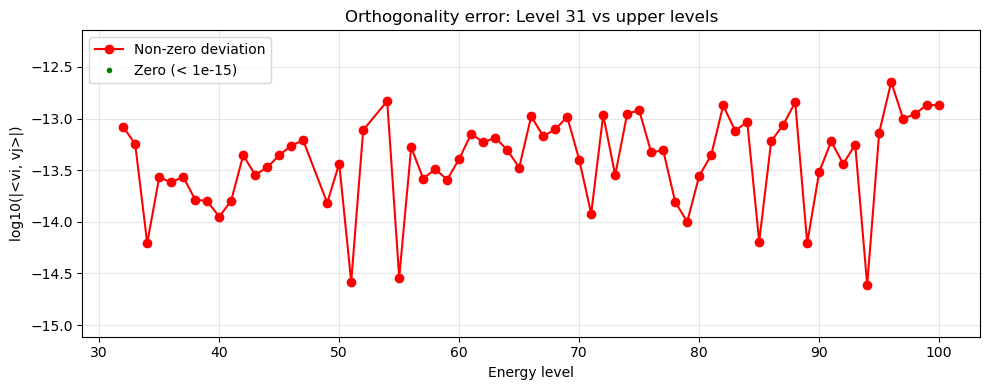

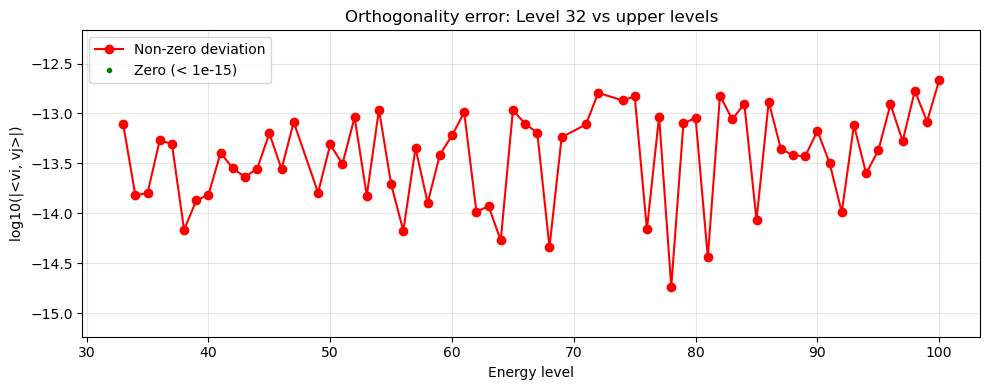

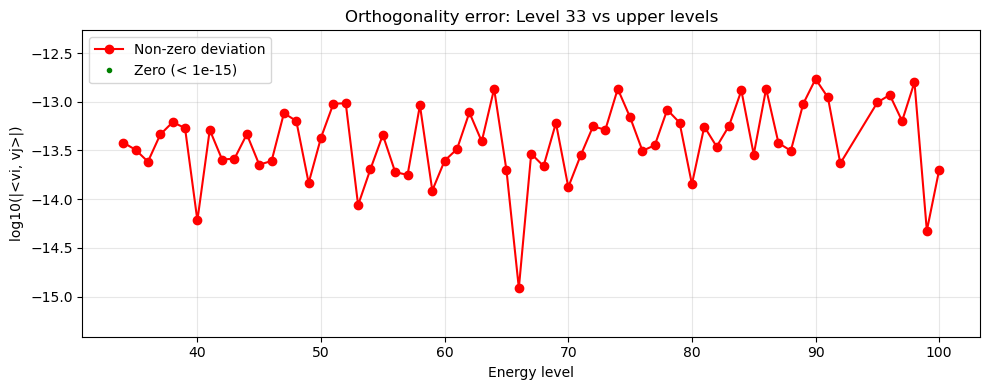

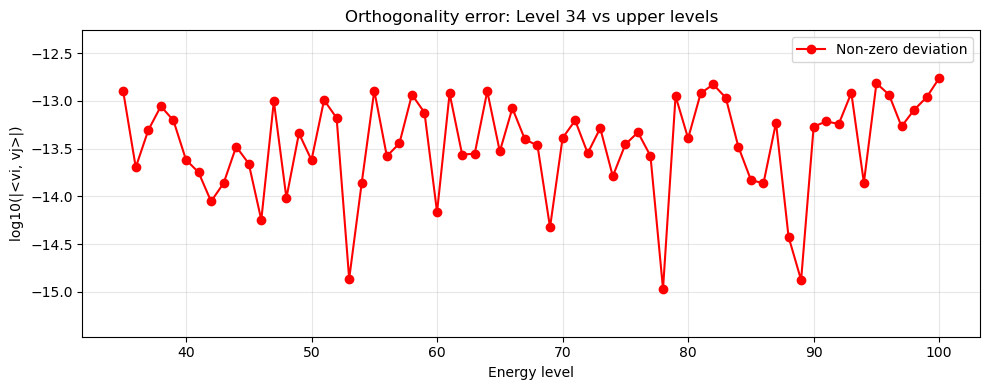

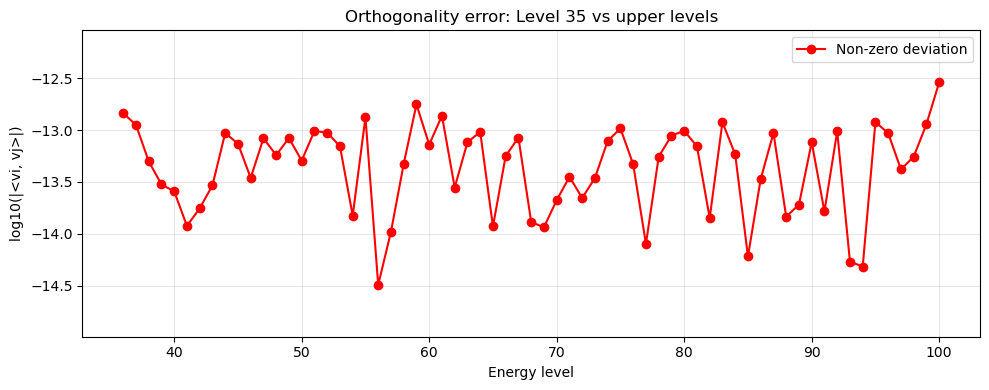

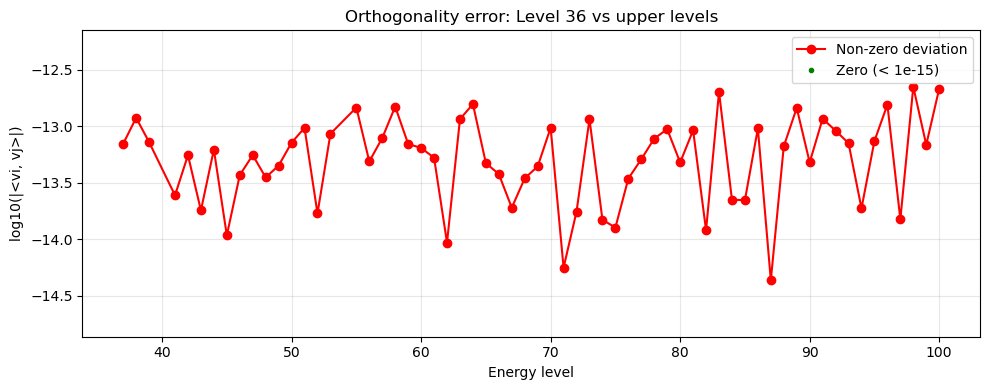

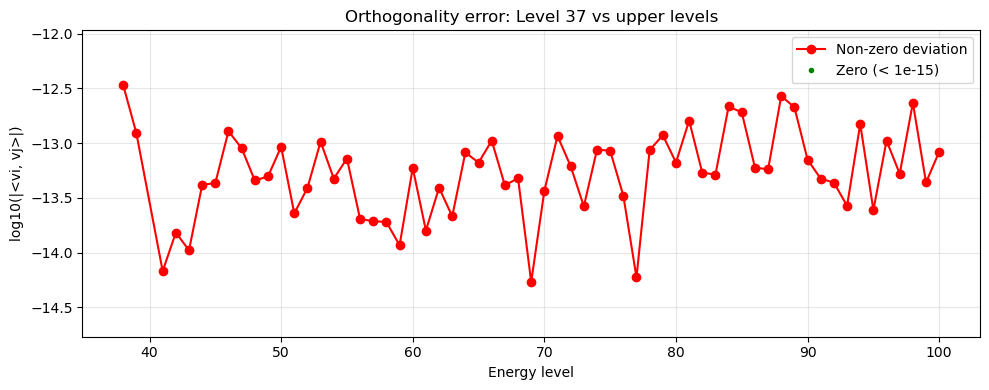

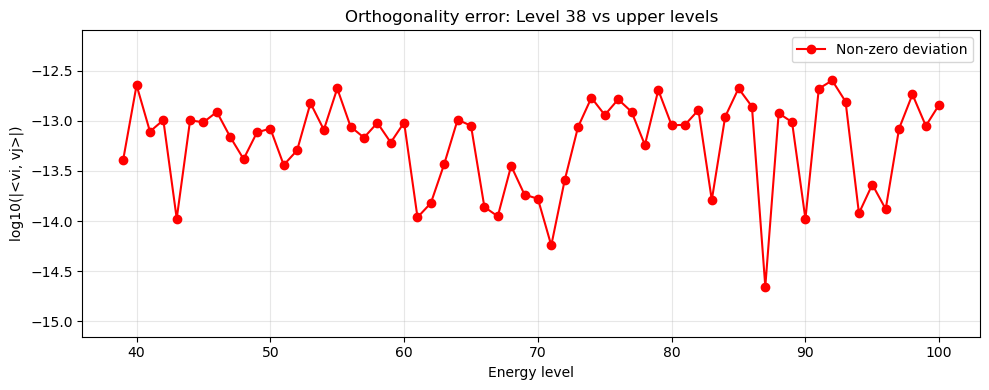

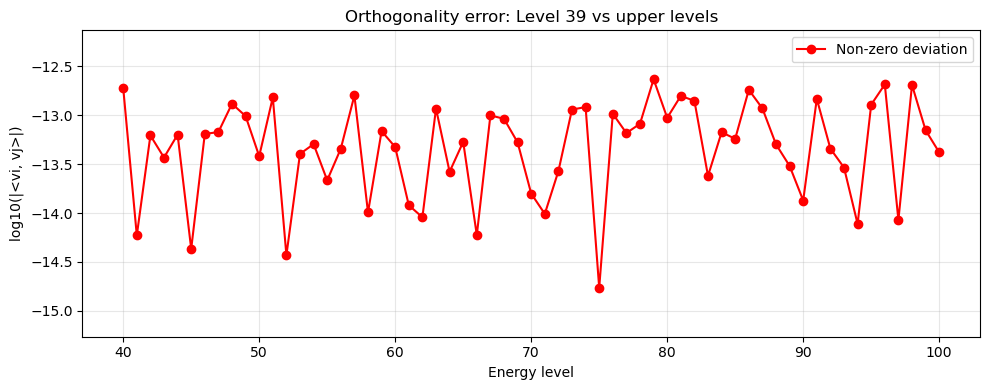

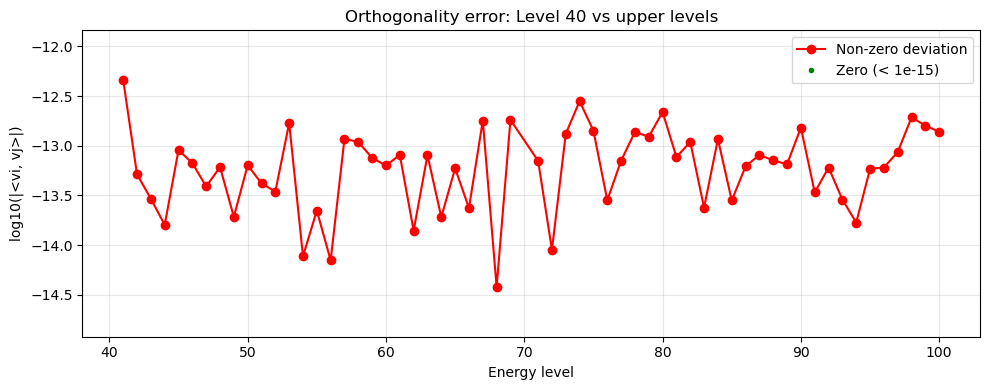

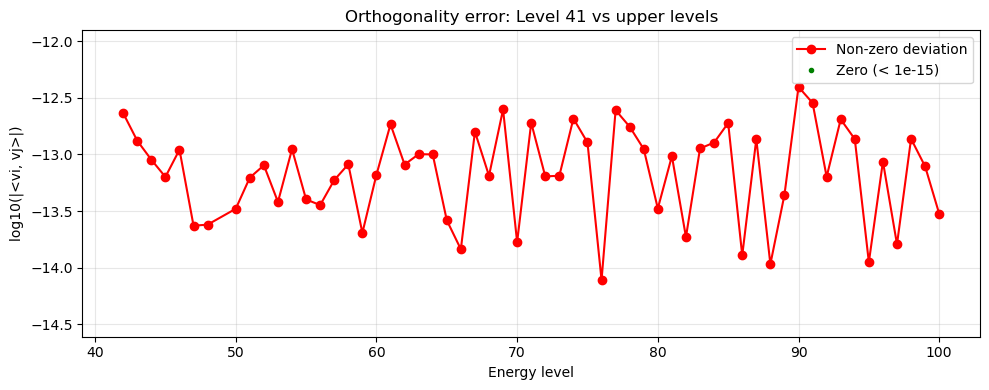

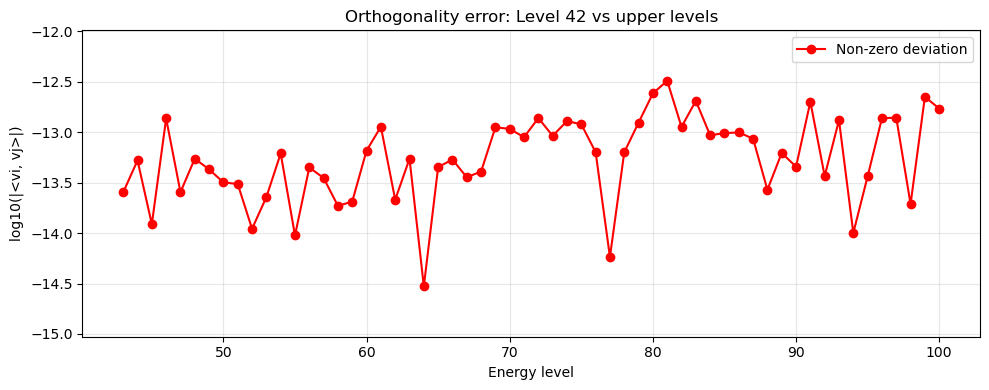

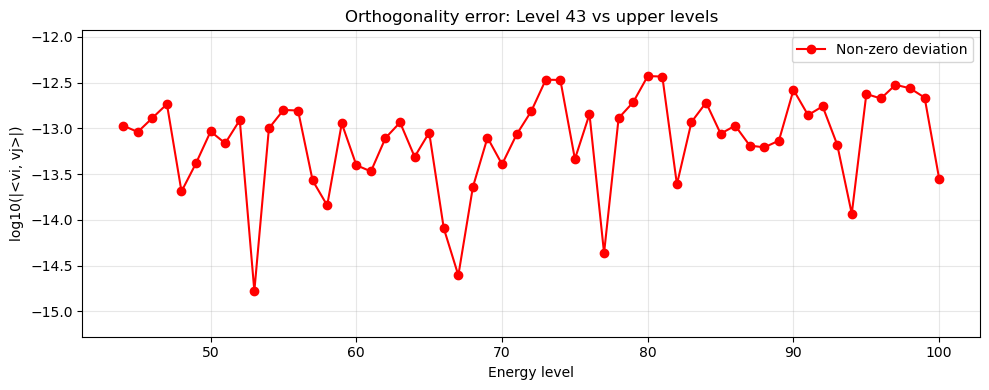

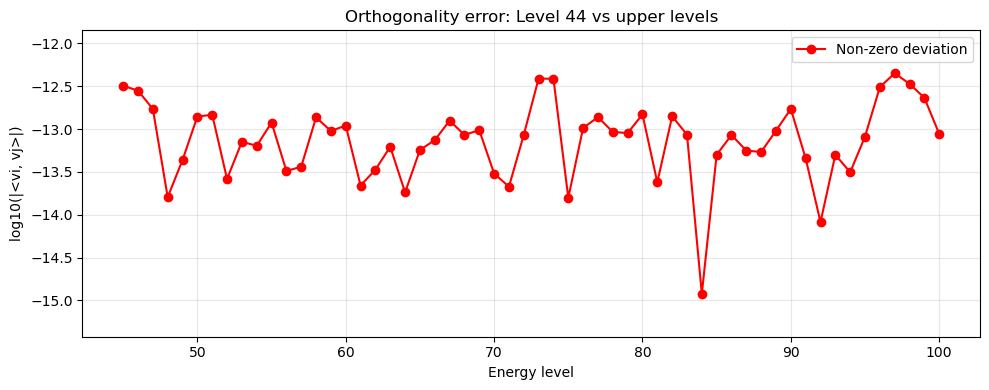

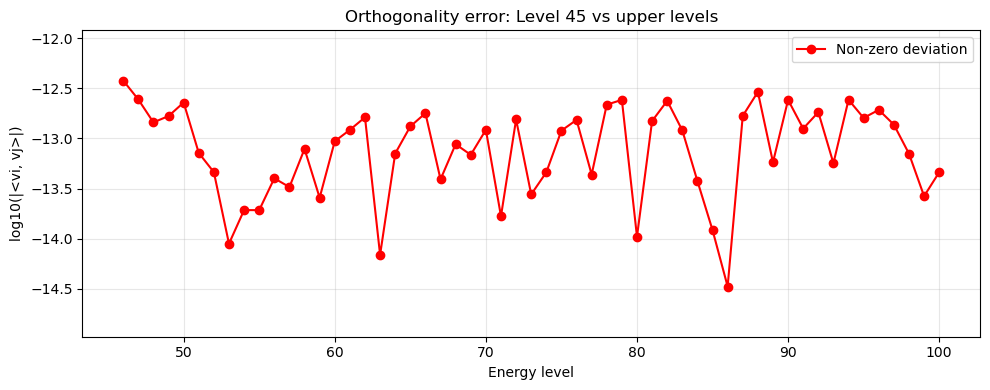

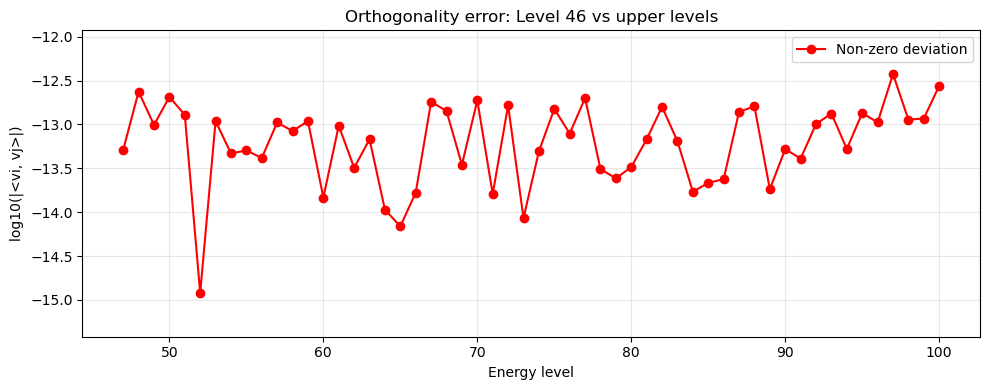

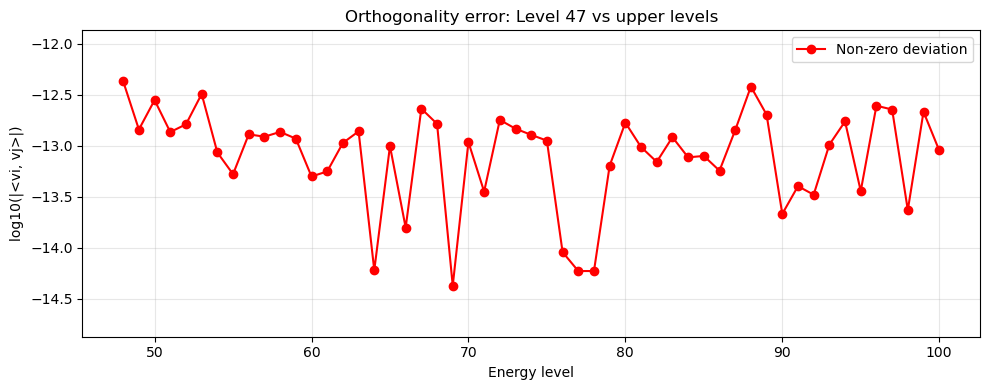

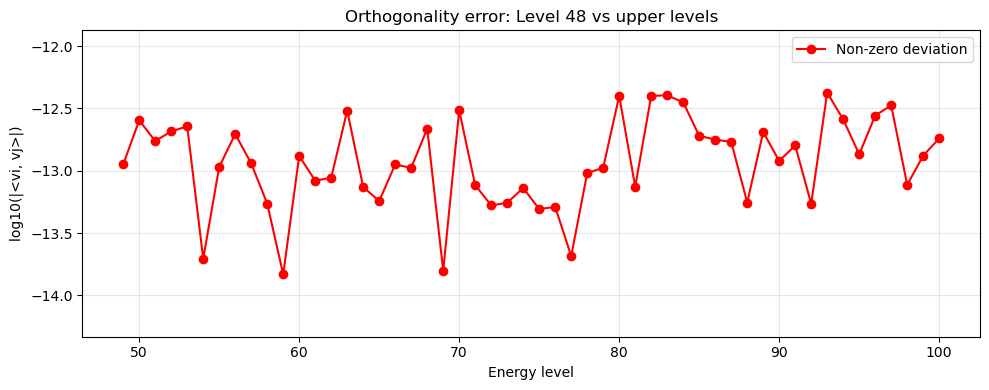

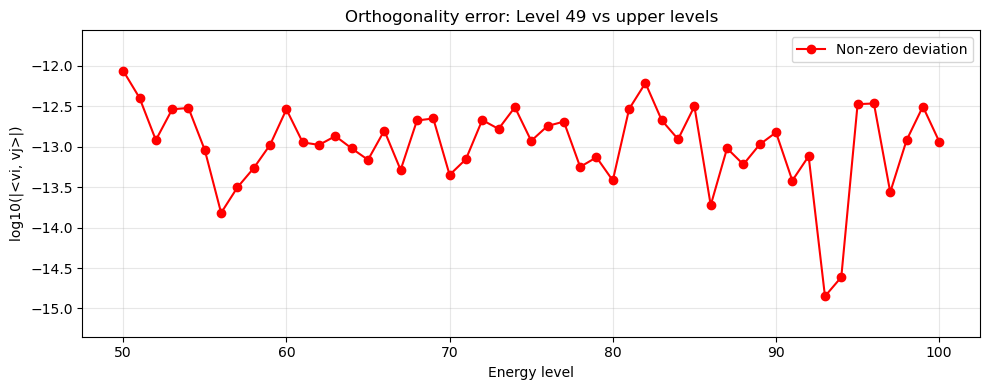

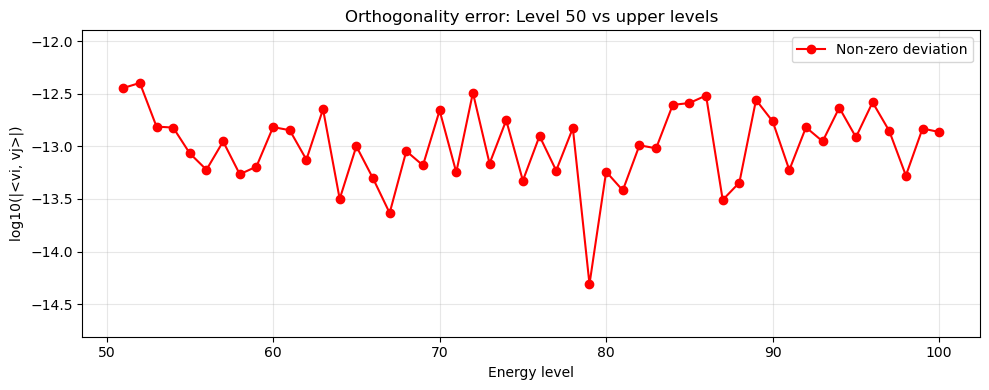

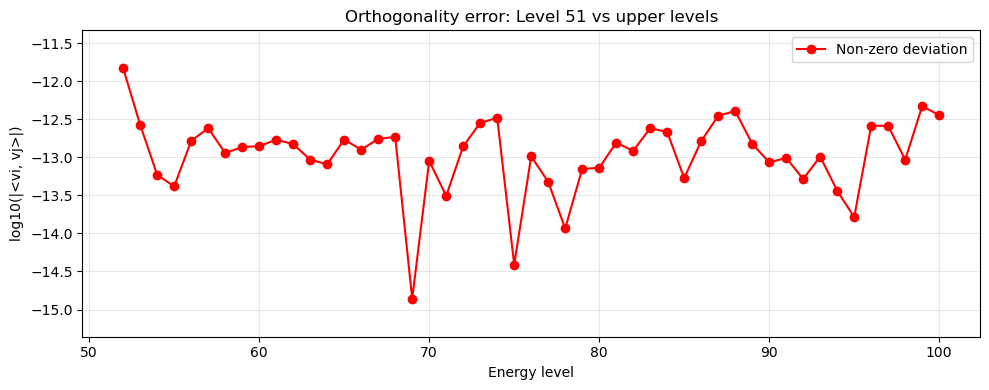

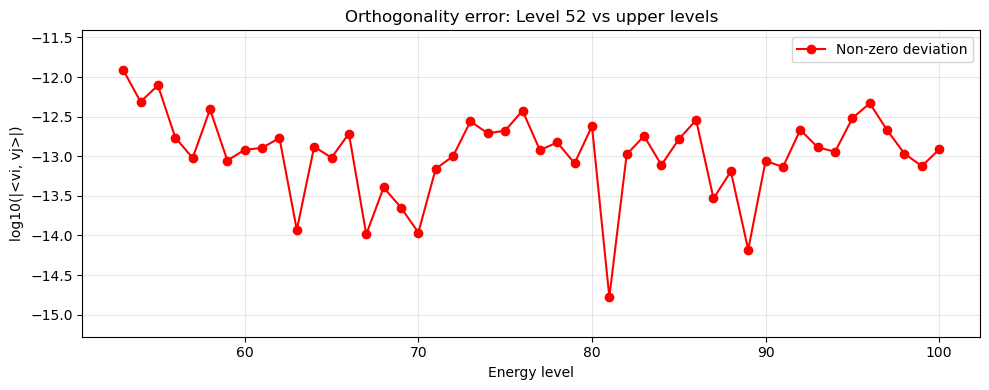

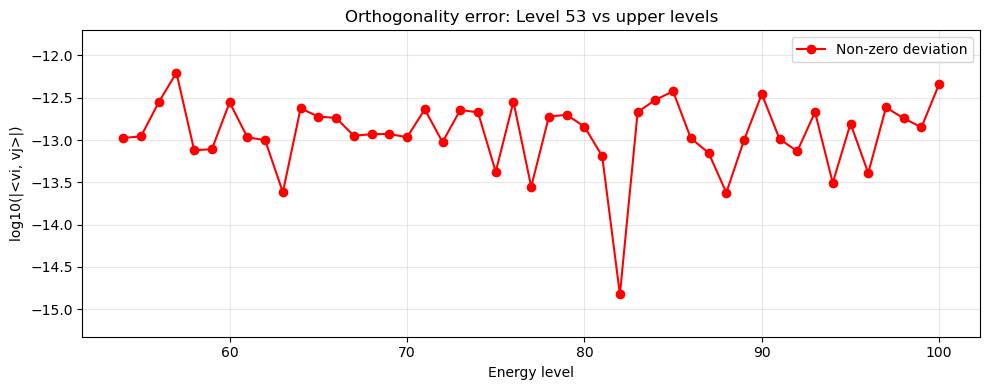

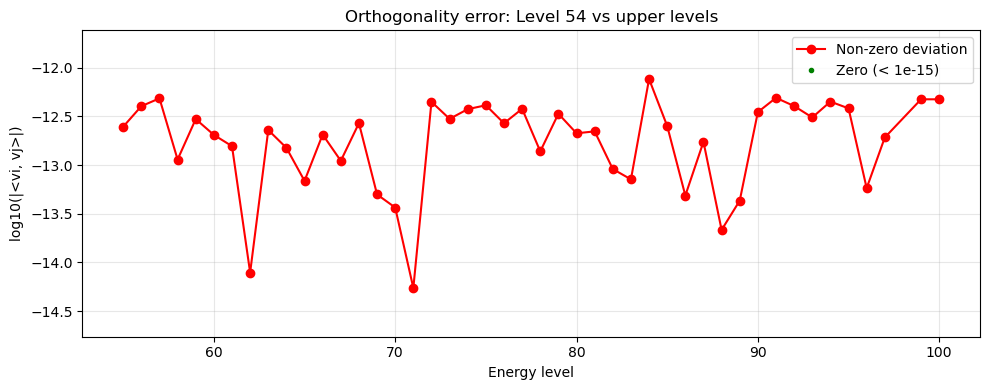

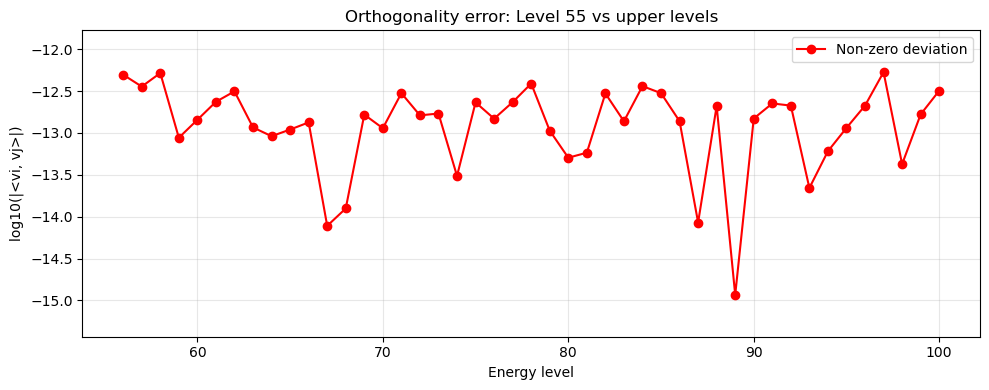

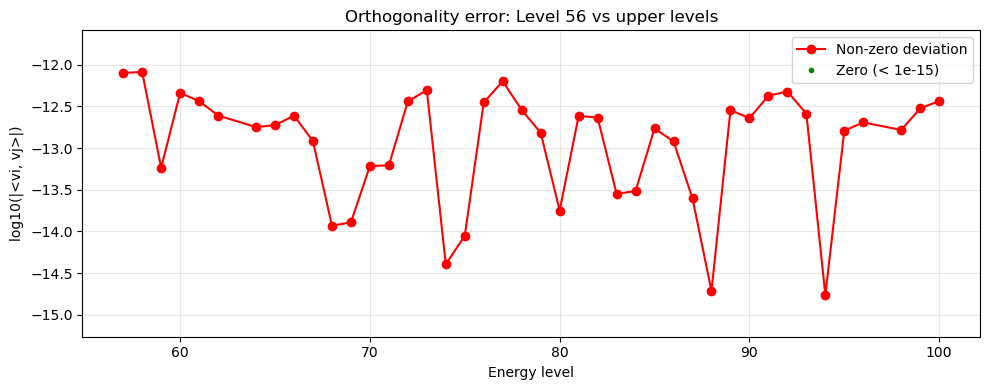

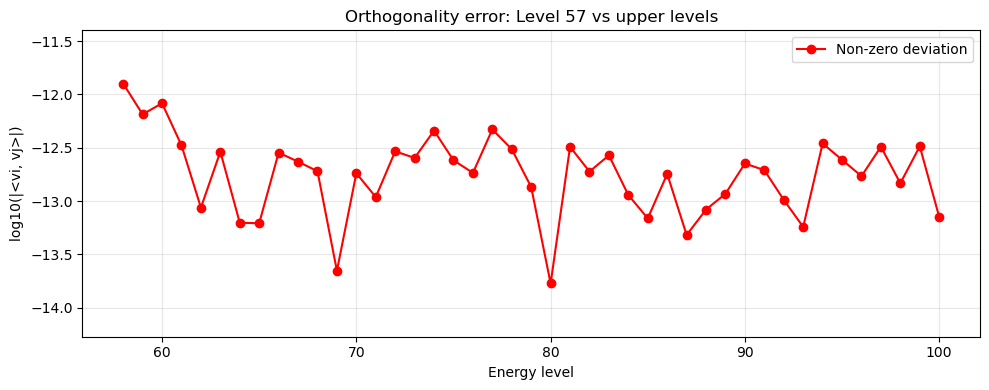

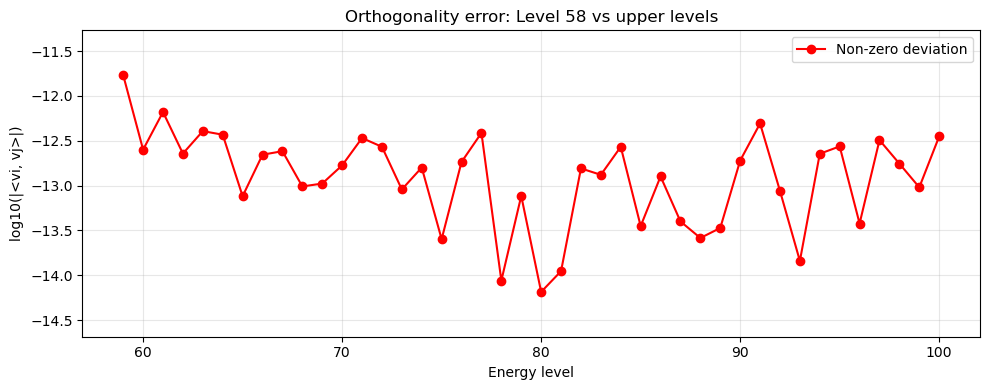

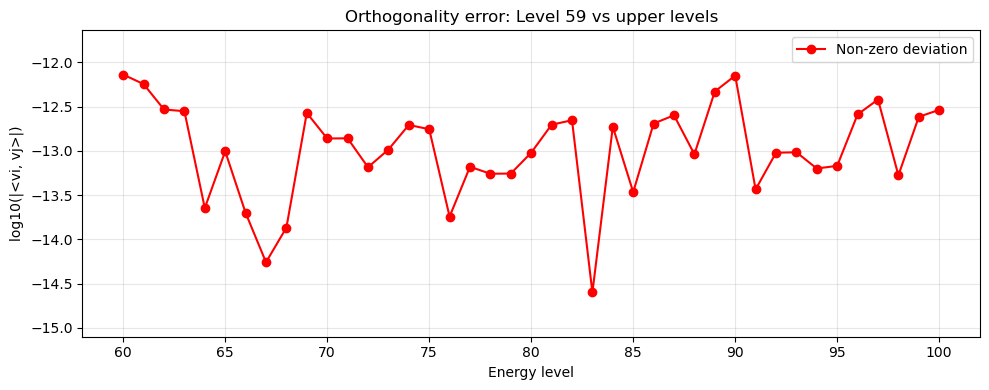

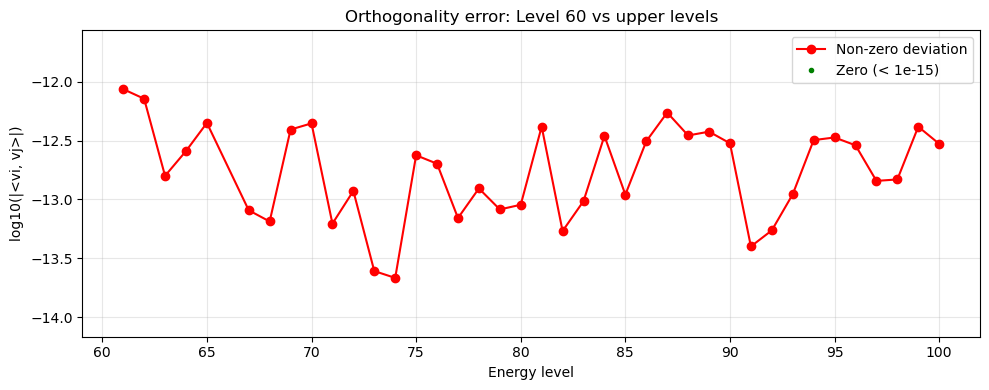

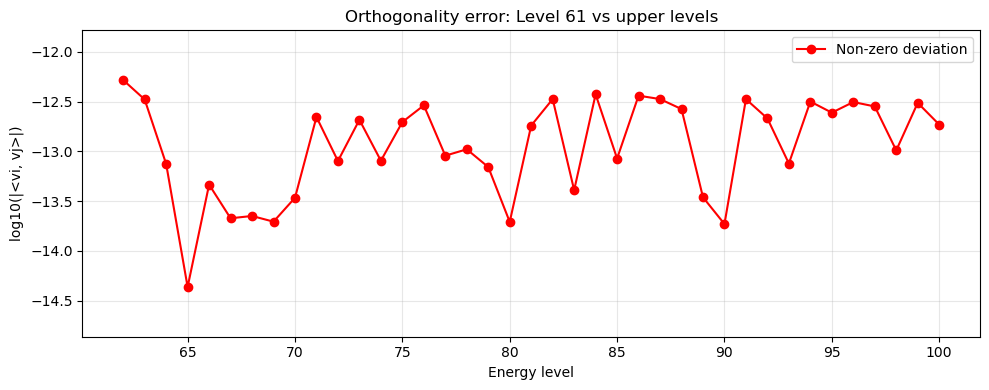

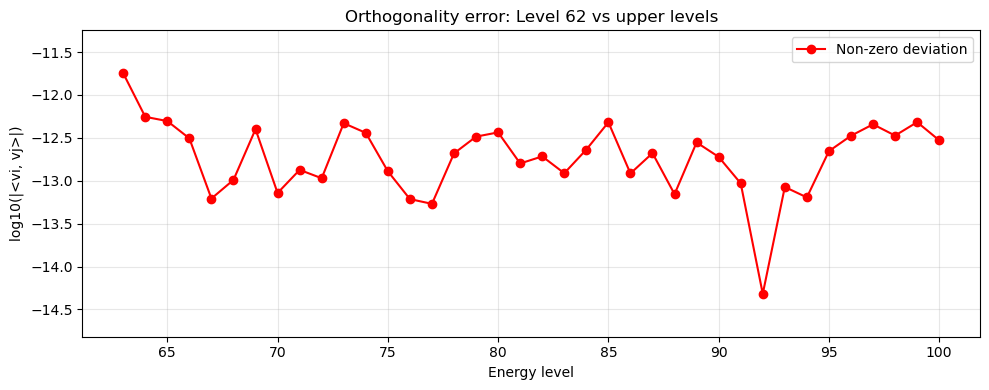

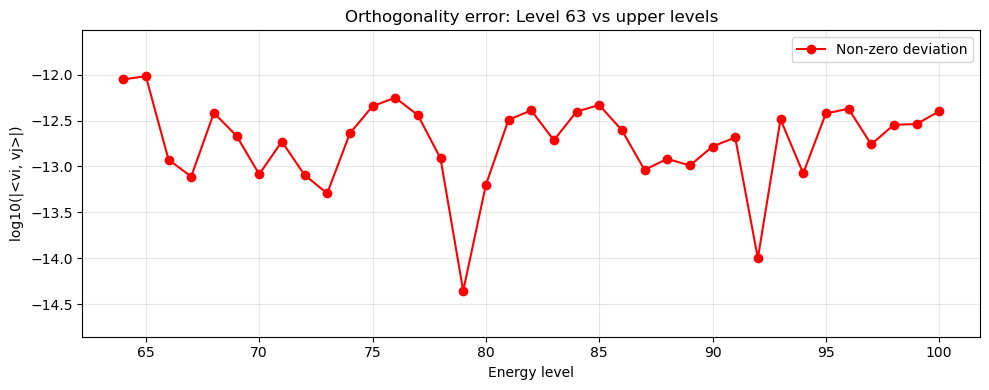

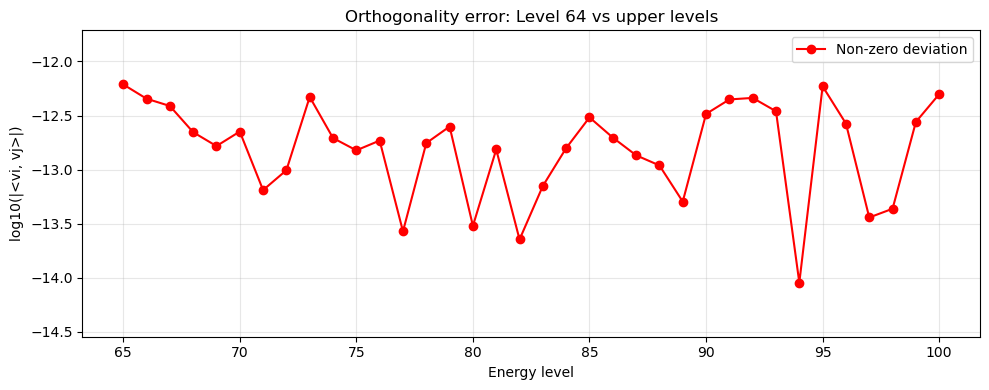

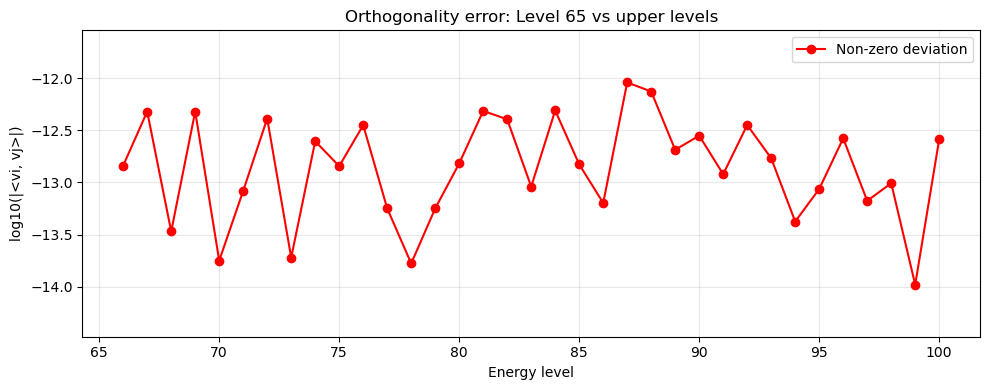

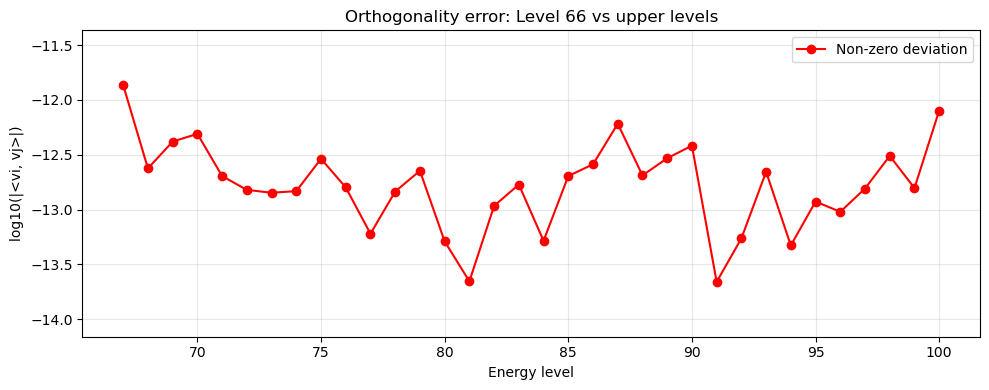

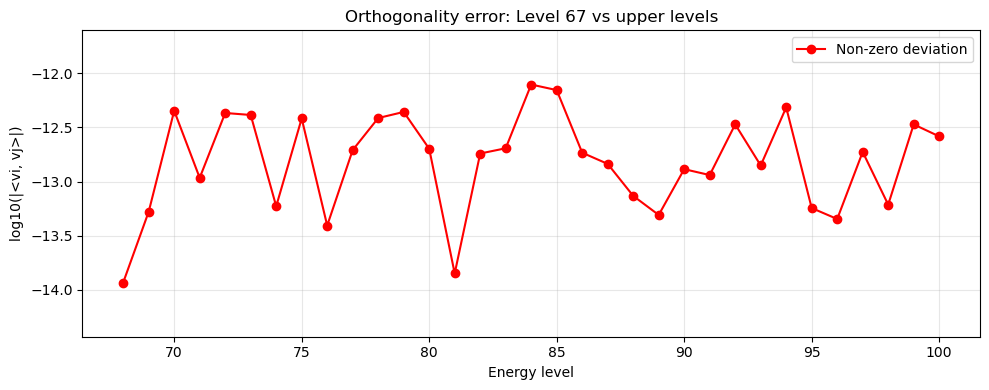

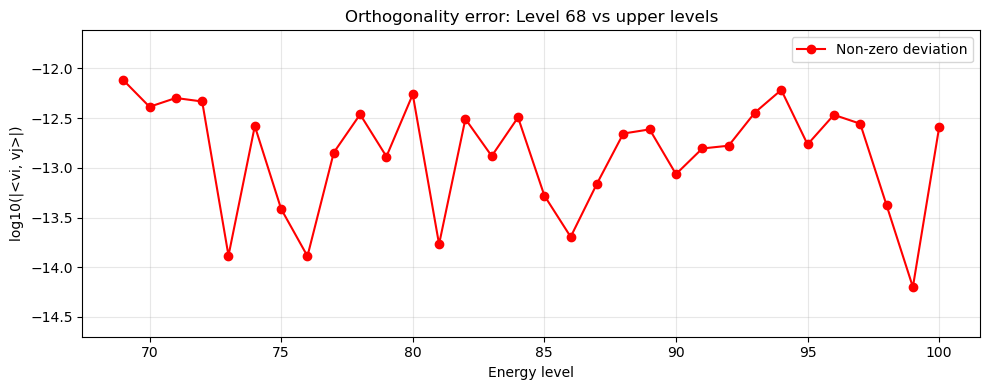

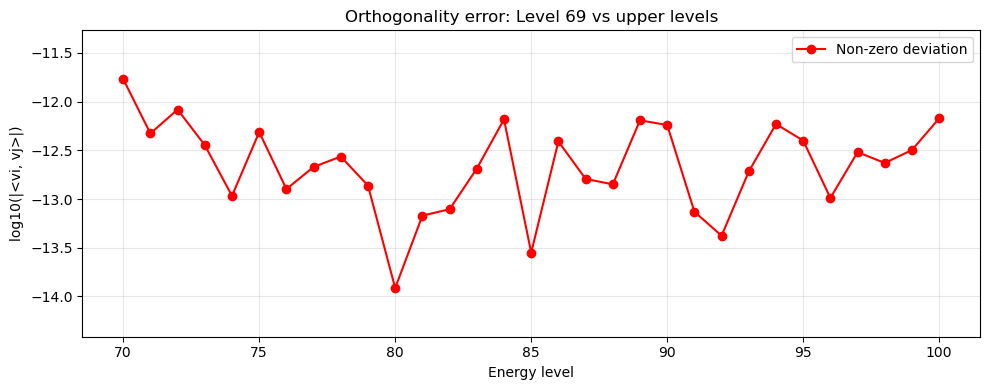

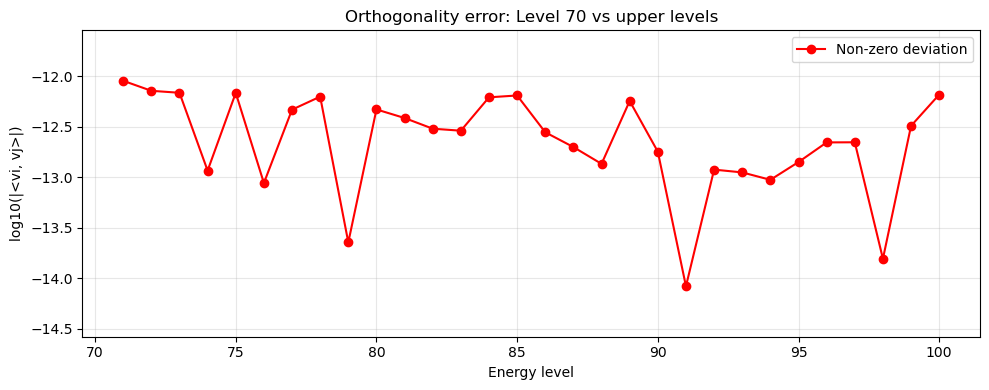

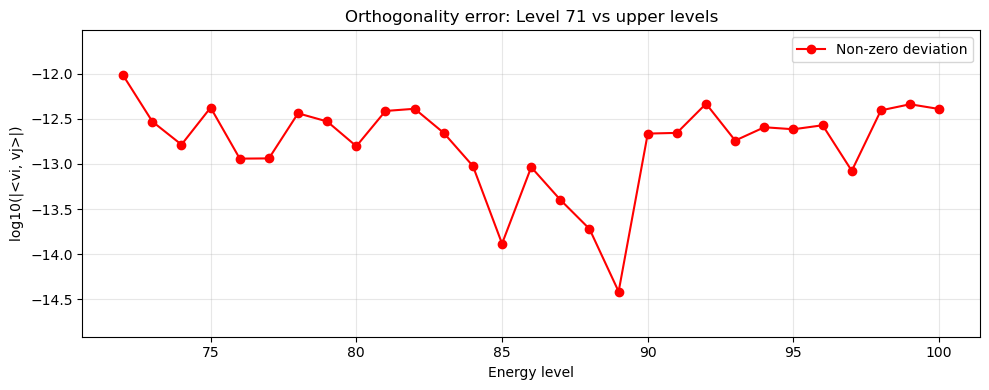

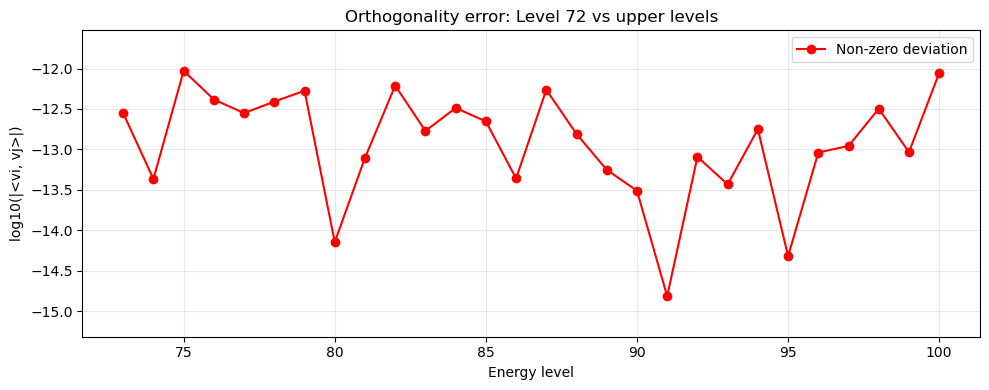

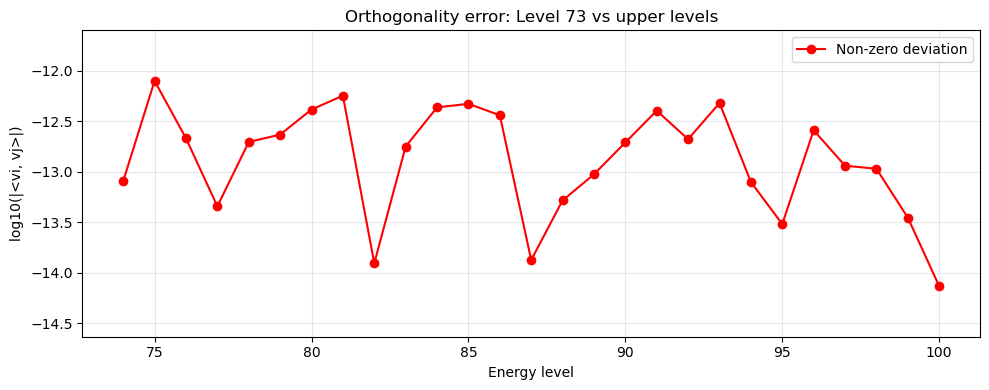

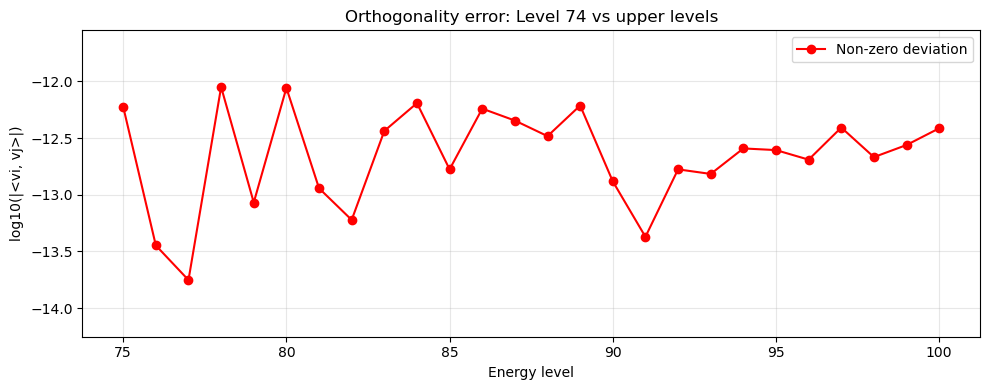

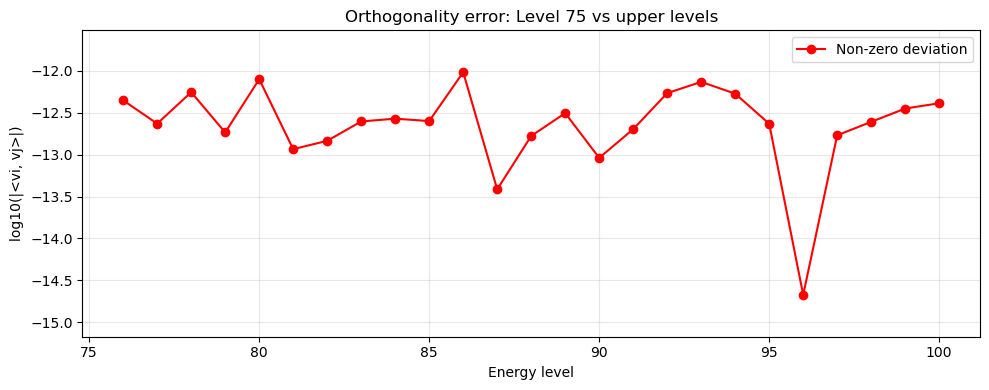

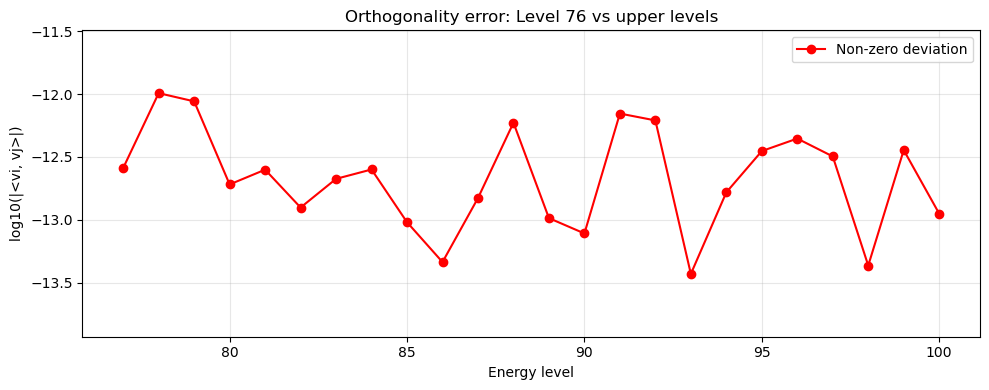

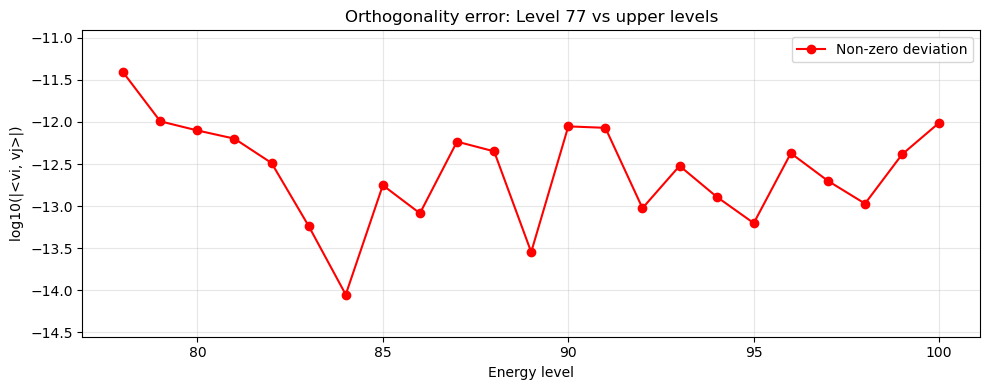

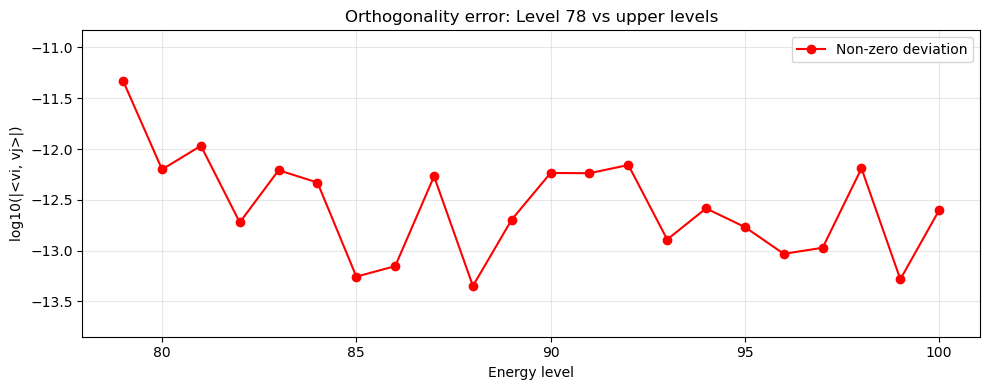

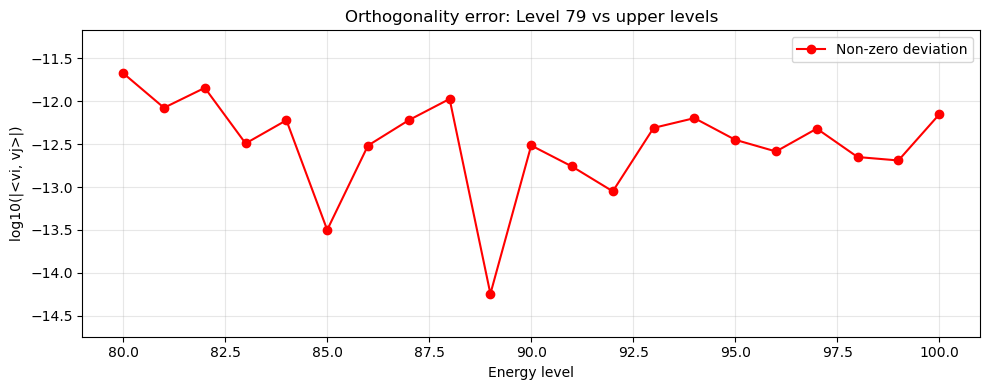

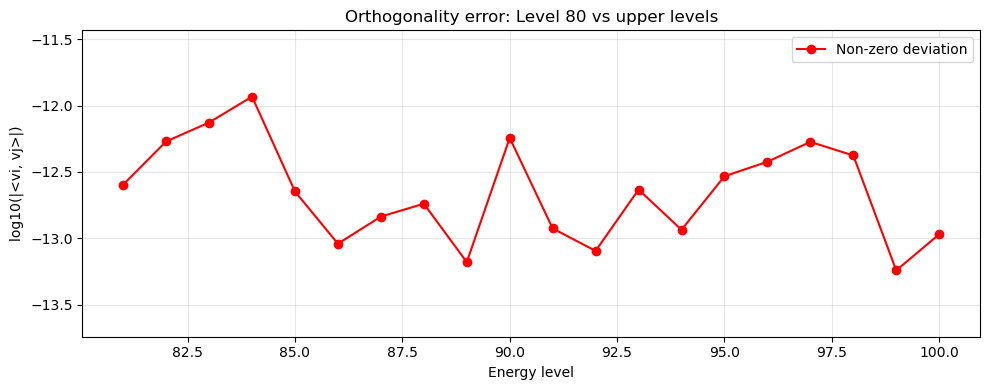

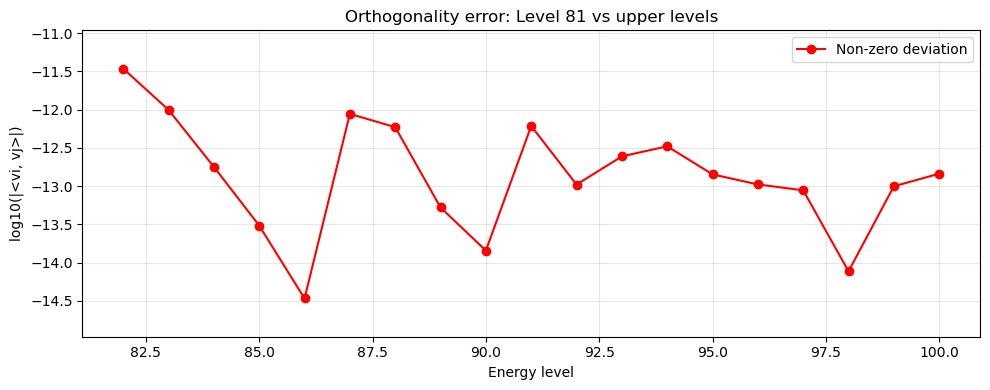

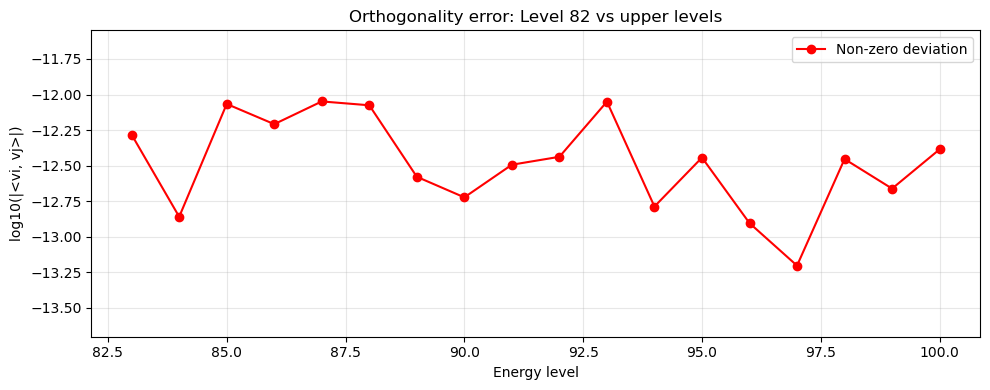

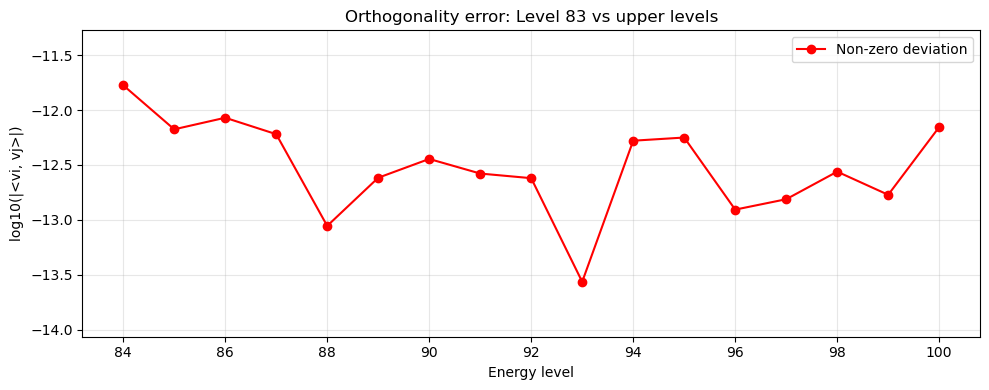

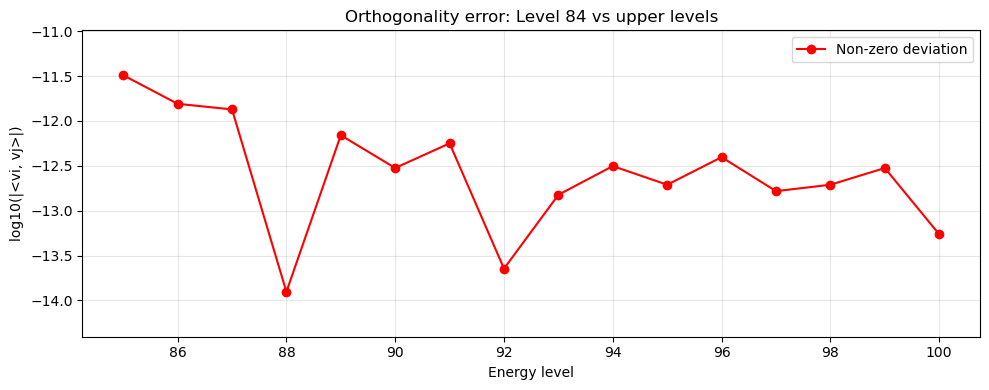

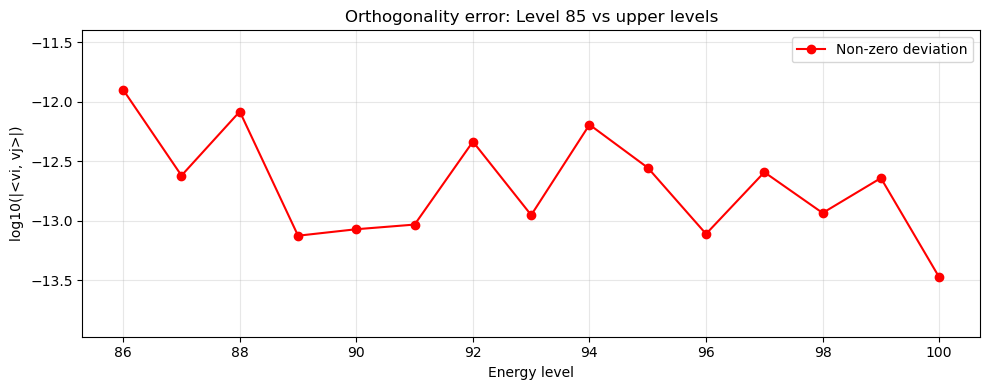

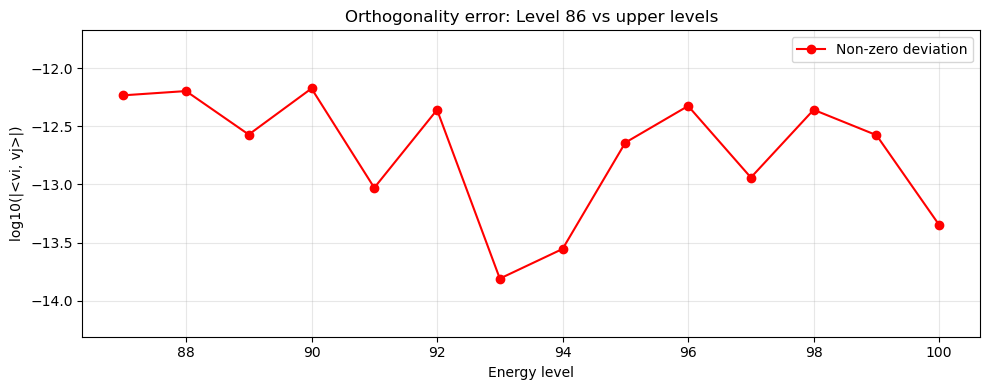

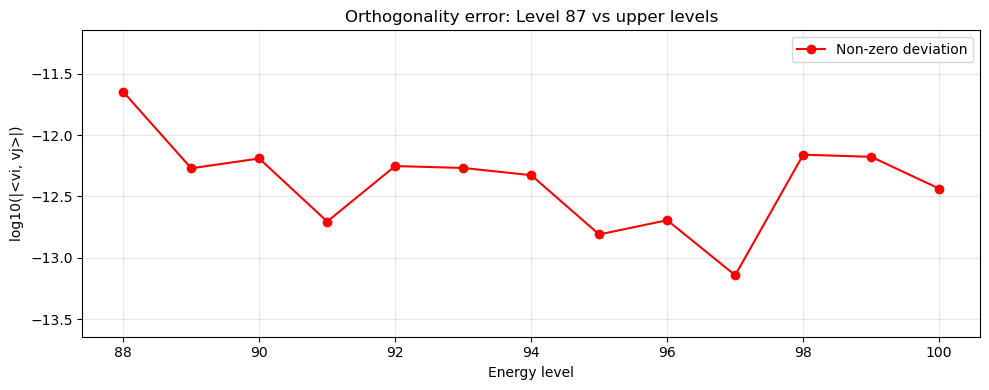

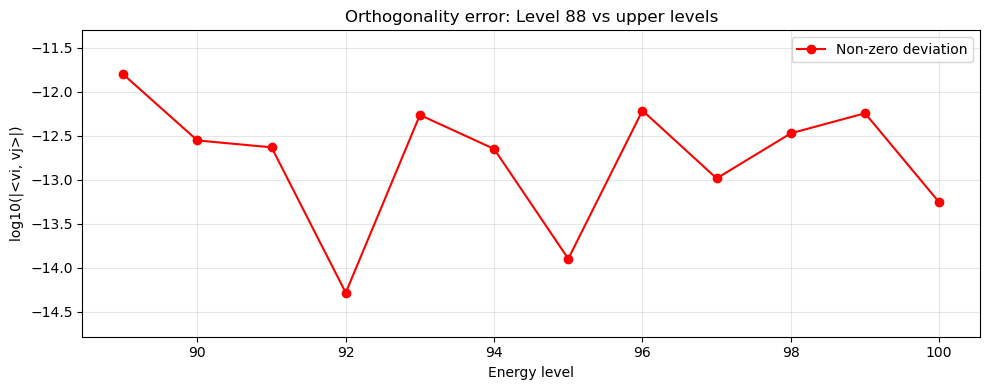

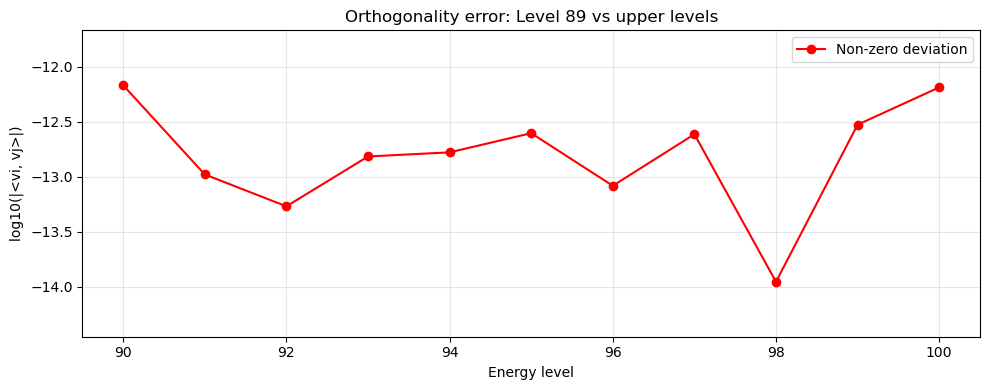

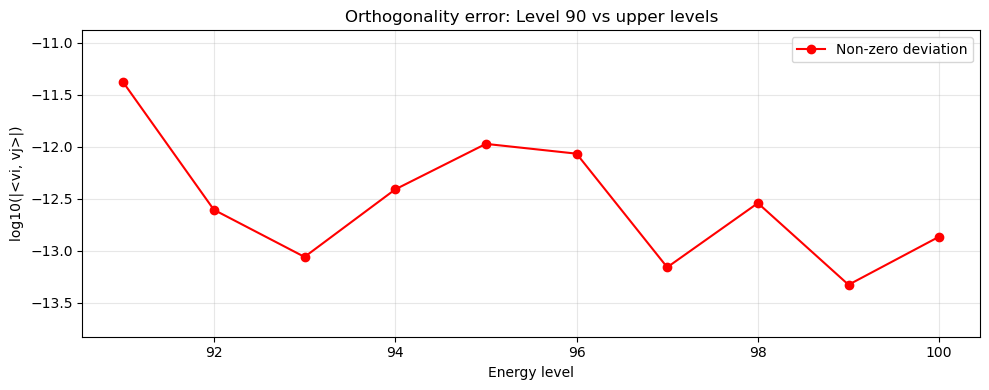

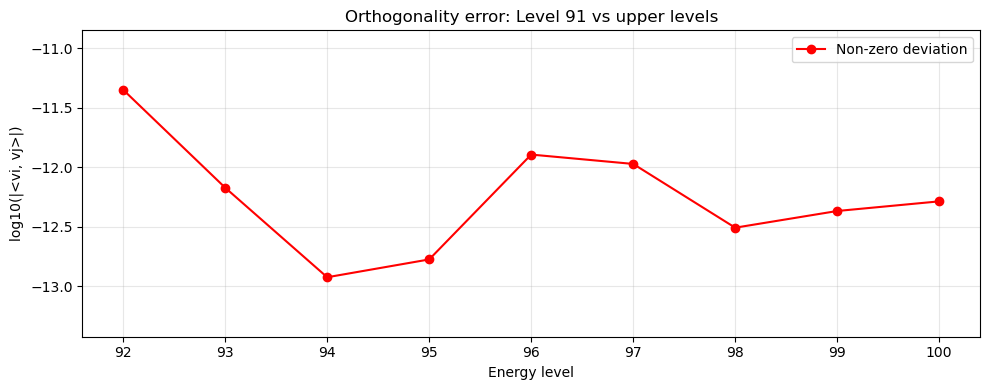

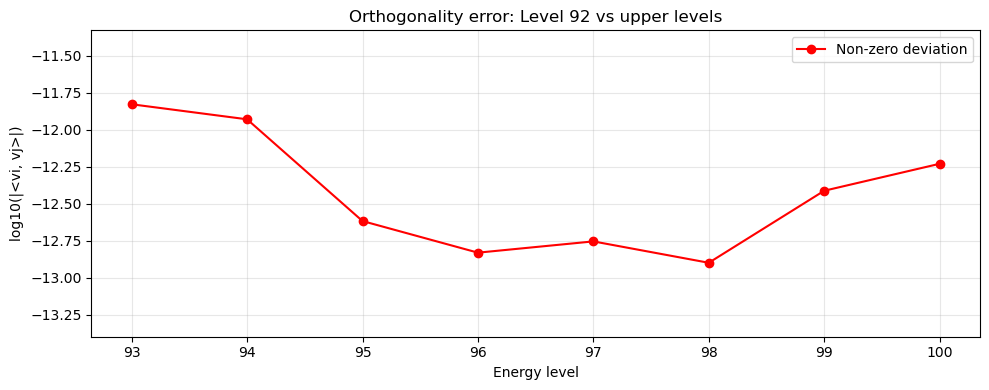

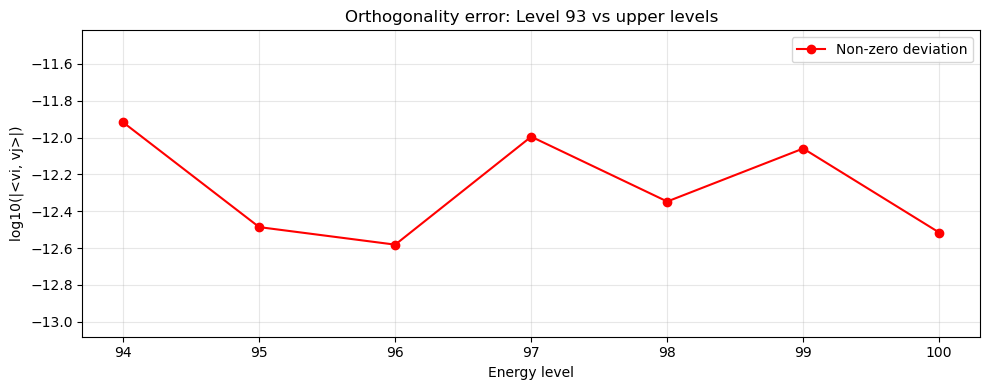

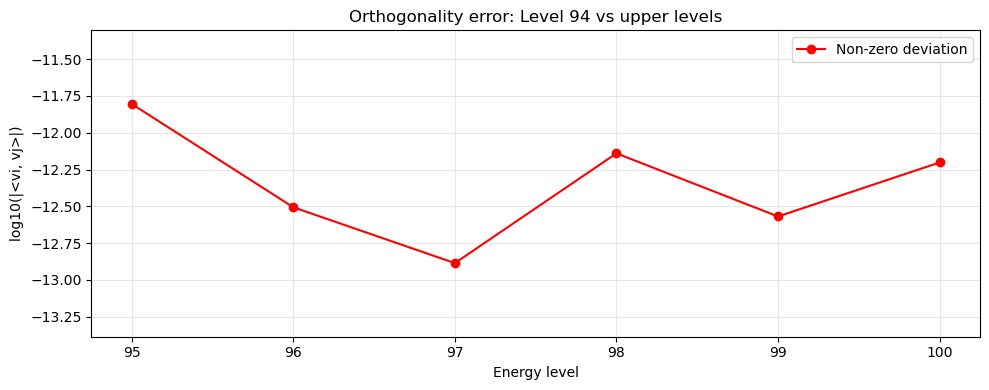

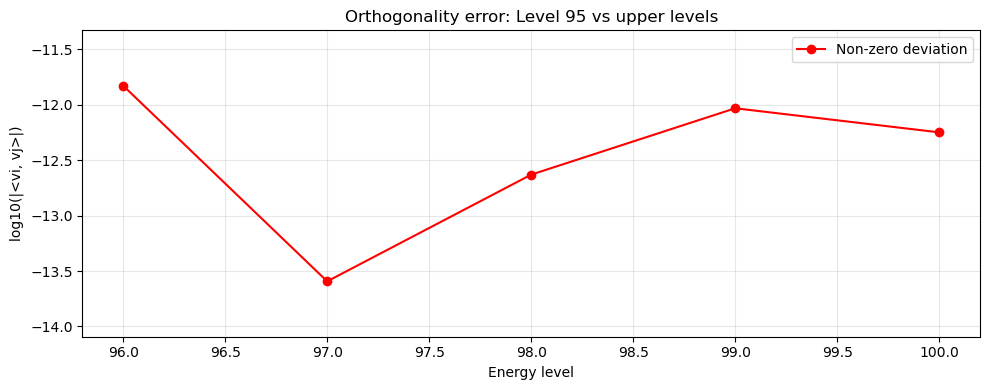

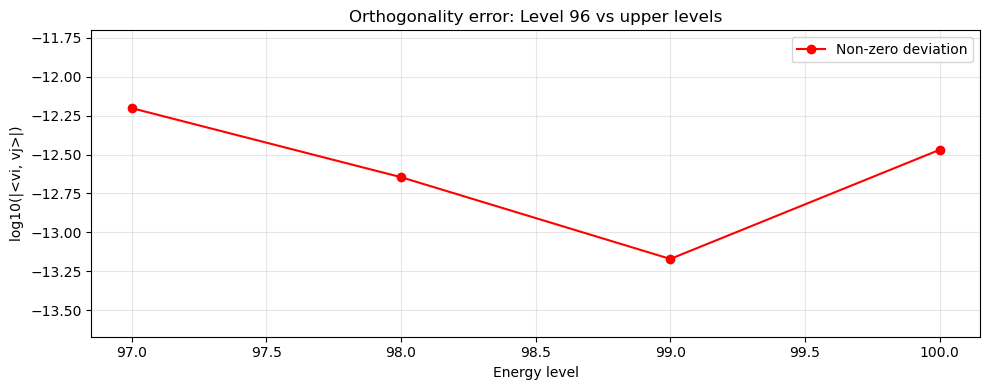

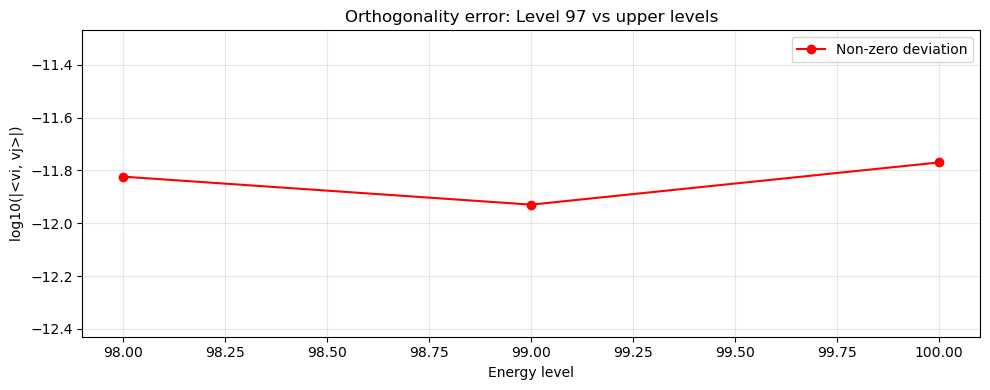

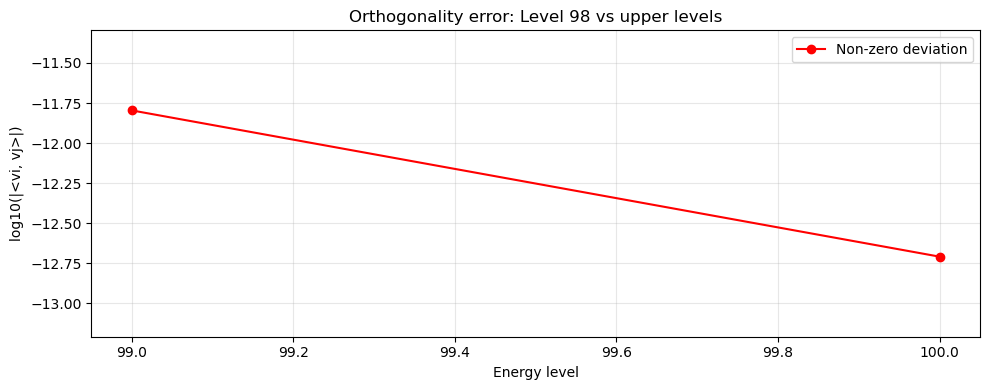

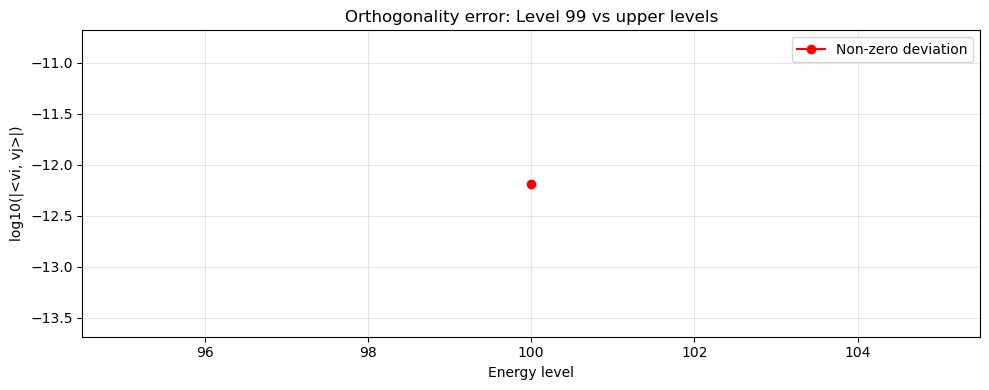

In [48]:
p.compare_graphically(q)

- Momentum

In [49]:
coefficients = [1, 1, 1] + [0] * 97

# **Create functions** to compute ⟨p⟩ and Δp **numerically**.
expected_momentum_func = p.expected_momentum(coefficients)
momentum_uncertainty_func = p.momentum_uncertainty(coefficients)

# **Compute** for **different values** of t.
# **Compute** for **different values** of t.
print(f"t=0: ⟨p⟩ = {expected_momentum_func(0)} | Δp = {momentum_uncertainty_func(0)}.")
print(f"t=10: ⟨p⟩ = {expected_momentum_func(10)} | Δp = {momentum_uncertainty_func(10)}.")

t=0: ⟨p⟩ = 0.0 | Δp = 3.896164793380968.
t=10: ⟨p⟩ = 2.493753106620395 | Δp = 2.978238157084891.


- plot_wavefunction_and_density

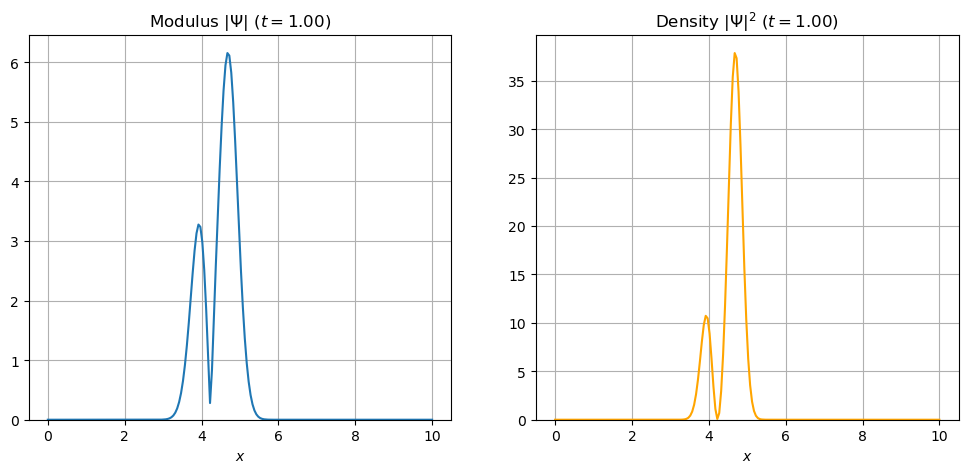

In [50]:
# Para t fixo:
p.plot_wavefunction_and_density(t=1.0, coefficients=coefficients)

In [51]:
# Para animação:
p.plot_wavefunction_and_density(t=(0, 10), coefficients=coefficients, save_as_gif=True)

Computing comparative frames…
-> GIF saved: StiffMatter/StiffMatter_wavefunction_density.gif.gif


- mydensityplot

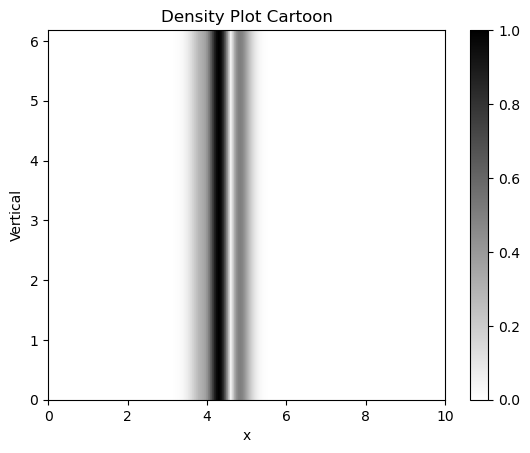

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Density Plot Cartoon'}, xlabel='x', ylabel='Vertical'>)

In [52]:
# Para o módulo da função de onda:
import numpy as np

p.mydensityplot(lambda x: np.abs(p.wave_function(x, t, coefficients)), x_label='x', a=0, b=p.length)

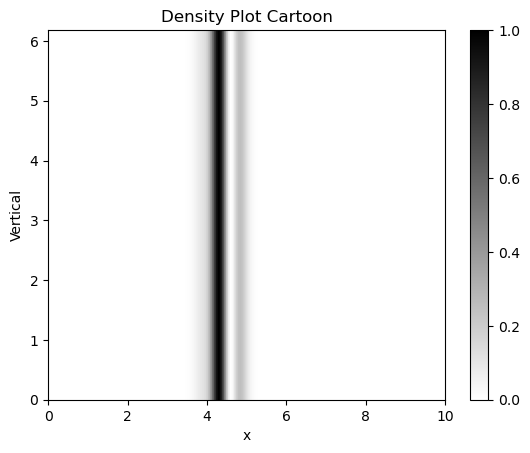

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Density Plot Cartoon'}, xlabel='x', ylabel='Vertical'>)

In [53]:
# Para a densidade de probabilidade:
p.mydensityplot(lambda x: np.abs(p.wave_function(x, t, coefficients))**2, x_label='x', a=0, b=p.length)

- L Optimizer

In [54]:
# Calcula o L ótimo
L_opt = p.optimize_length() 

# Resultados obtidos
print(f"L ótimo: {L_opt:.15f}")

L ótimo: 8.325675422789727
